## Effective radius

As the REFF_AERO variable showed little growth after Pinatubo, I'll try to see if there is another way to look at it, or if the modes are better to look at seperately.

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal
import seaborn as sns

In [2]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43953 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:43953/status,
Dashboard: http://127.0.0.1:43953/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33599,Workers: 0
Dashboard: http://127.0.0.1:43953/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35113,Total threads: 4
Dashboard: http://127.0.0.1:42165/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:33449,


In [4]:
path_atm_22 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251125_pinatubo10Tg22_e01/atm/hist"
ds_22 = xr.open_mfdataset(f"{path_atm_22}/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01.cam.h0.*.nc", combine="by_coords", parallel=True)


Exception ignored in: <function CachingFileManager.__del__ at 0x7fca0f9defc0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [5]:
path_atm_19_c =  "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20260116_pinatubo10tg_19_c/atm/hist"
ds_19_c = xr.open_mfdataset(f"{path_atm_19_c}/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7fca0f9defc0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [6]:
path_atm_24 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251129_pinatubo17Tg24_e01/atm/hist"
ds_24 = xr.open_mfdataset(f"{path_atm_24}/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7fca0f9defc0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [7]:
path_atm = "/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
ds_19 = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.199*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7fca0f9defc0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [9]:
path_atm_1825 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251204_pinatubo10Tg18_25_e01/atm/hist"
ds_1825 = xr.open_mfdataset(f"{path_atm_1825}/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [10]:
path_atm_1825_17tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251207_pinatubo17Tg18_25_e01/atm/hist"
ds_1825_17tg = xr.open_mfdataset(f"{path_atm_1825_17tg}/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [11]:
path_atm_1tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251210_pinatubo1Tg19_e01/atm/hist"
ds_1tg = xr.open_mfdataset(f"{path_atm_1tg}/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [12]:
path_atm_1pr = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251223_pinatubo10Tg_1pr/atm/hist"
ds_1pr = xr.open_mfdataset(f"{path_atm_1pr}/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr.cam.h0.*.nc", combine="by_coords", parallel=True)

In [13]:
path_atm_60tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20260108_pinatubo60Tg19_e01/atm/hist"
ds_60tg = xr.open_mfdataset(f"{path_atm_60tg}/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19.cam.h0.*.nc", combine="by_coords", parallel=True)

In [14]:
client.close()

In [15]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19['time'].values])
ds_19 = ds_19.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])
ds_22 = ds_22.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])
ds_19_c = ds_19_c.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])
ds_24 = ds_24.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825['time'].values])
ds_1825 = ds_1825.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825_17tg['time'].values])
ds_1825_17tg = ds_1825_17tg.assign_coords(time=shifted_time)

In [16]:
shifted_time = np.array([shift_one_month_back(t) for t in ds_1tg['time'].values])
ds_1tg = ds_1tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1pr['time'].values])
ds_1pr = ds_1pr.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_60tg['time'].values])
ds_60tg = ds_60tg.assign_coords(time=shifted_time)

In [17]:
lat_19 = ds_19["lat"]
weighted_lat_19 = np.cos(np.deg2rad(lat_19))
lat_19_c = ds_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))
lat_22 = ds_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat_22))
lat_24 = ds_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat_24))
lat_1825 = ds_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat_1825))
lat_1825_17tg = ds_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat_1825_17tg))
lat_1tg = ds_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat_1tg))
lat_1pr = ds_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat_1pr))
lat_60tg = ds_60tg["lat"]
weighted_lat_60tg = np.cos(np.deg2rad(lat_60tg))

In [18]:
ds_19_c["lev"]

<xarray.DataArray 'lev' (lev: 32)> Size: 256B
array([  3.643466,   7.59482 ,  14.356632,  24.61222 ,  35.92325 ,  43.19375 ,
        51.677499,  61.520498,  73.750958,  87.82123 , 103.317127, 121.547241,
       142.994039, 168.22508 , 197.908087, 232.828619, 273.910817, 322.241902,
       379.100904, 445.992574, 524.687175, 609.778695, 691.38943 , 763.404481,
       820.858369, 859.534767, 887.020249, 912.644547, 936.198398, 957.48548 ,
       976.325407, 992.556095])
Coordinates:
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
Attributes:
    long_name:      hybrid level at midpoints (1000*(A+B))
    units:          hPa
    positive:       down
    standard_name:  atmosphere_hybrid_sigma_pressure_coordinate
    formula_terms:  a: hyam b: hybm p0: P0 ps: PS

In [19]:
tropopause_19 = ds_19["TROP_P"].weighted(weighted_lat_19).mean(dim=["lat", "lon"])
p_lev_19 = tropopause_19 * 0.01
tropopause_19_c = ds_19_c["TROP_P"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
p_lev_19_c = tropopause_19_c * 0.01
tropopause_22 = ds_22["TROP_P"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
p_lev_22 = tropopause_22 * 0.01
tropopause_24 = ds_24["TROP_P"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
p_lev_24 = tropopause_24 * 0.01
tropopause_1825 = ds_1825["TROP_P"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
p_lev_1825 = tropopause_1825 * 0.01
tropopause_1825_17tg = ds_1825_17tg["TROP_P"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
p_lev_1825_17tg = tropopause_1825_17tg * 0.01
tropopause_1tg = ds_1tg["TROP_P"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
p_lev_1tg = tropopause_1tg * 0.01
tropopause_1pr = ds_1pr["TROP_P"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
p_lev_1pr = tropopause_1pr * 0.01
tropopause_60tg = ds_60tg["TROP_P"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
p_lev_60tg = tropopause_60tg * 0.01

In [20]:
"""def compute_SReff(ds, p_lev=None, p_lev_upper=None, p_lev_lower=None,
                  lat_range=None, lon_range=None,
                  weighted_lat=None, weighted_lev=None,
                  cm_to_mym=10000):
    
    da = ds["REFF_AERO"]
    
    if p_lev is not None:
        da = da.sel(lev = p_lev, method="nearest")
    elif p_lev_upper is not None and p_lev_lower is not None:
        da = da.where((da["lev"] >= p_lev_upper) & (da["lev"] <= p_lev_lower))
    elif p_lev_lower is not None:
        da = da.where(da["lev"] <= p_lev_lower)
    
    if lat_range:
        da = da.sel(lat=slice(*lat_range))
    if lon_range:
        da = da.sel(lon=slice(*lon_range))
    
    da = da.weighted(weighted_lat).mean(dim=["lat","lon"]) * cm_to_mym
    da = da.weighted(weighted_lev).mean(dim="lev")
    
    return da"""


'def compute_SReff(ds, p_lev=None, p_lev_upper=None, p_lev_lower=None,\n                  lat_range=None, lon_range=None,\n                  weighted_lat=None, weighted_lev=None,\n                  cm_to_mym=10000):\n\n    da = ds["REFF_AERO"]\n\n    if p_lev is not None:\n        da = da.sel(lev = p_lev, method="nearest")\n    elif p_lev_upper is not None and p_lev_lower is not None:\n        da = da.where((da["lev"] >= p_lev_upper) & (da["lev"] <= p_lev_lower))\n    elif p_lev_lower is not None:\n        da = da.where(da["lev"] <= p_lev_lower)\n\n    if lat_range:\n        da = da.sel(lat=slice(*lat_range))\n    if lon_range:\n        da = da.sel(lon=slice(*lon_range))\n\n    da = da.weighted(weighted_lat).mean(dim=["lat","lon"]) * cm_to_mym\n    da = da.weighted(weighted_lev).mean(dim="lev")\n\n    return da'

In [21]:
da_2d = ds_19["REFF_AERO"].sel(lat=slice(-20, 20)).mean(dim=["lat", "lon"])

mask = np.zeros(da_2d.shape, dtype=bool)
for t in range(da_2d.shape[0]):
    limit = p_lev_19.values[t]
    mask[t, :] = (da_2d.lev >= 3.64) & (da_2d.lev <= limit)

da_strat = da_2d.where(mask)
SReff_simple = da_strat.mean(dim="lev", skipna=True) * 10000

lev_diff = np.gradient(da_2d.lev.values)
weights = xr.DataArray(lev_diff, coords={'lev': da_2d.lev}, dims=['lev'])

numerator = (da_strat * weights).sum(dim="lev", skipna=True)
denominator = weights.where(~np.isnan(da_strat)).sum(dim="lev", skipna=True)
SReff_weighted = (numerator / denominator) * 10000

print("Simple mean (first 5):", SReff_simple.values[:5])
print("Weighted mean (first 5):", SReff_weighted.values[:5])

Simple mean (first 5): [0.11728722 0.11836649 0.11665025 0.1176851  0.11857684]
Weighted mean (first 5): [0.12031292 0.12179025 0.12190569 0.12413829 0.1252139 ]


In [22]:
def compute_SReff_hybrid(ds, p_lev_lower, lat_range=None, lon_range=None, p_lev_upper=3.643466):
    temp_ds = ds.sel(lat=slice(*lat_range)) if lat_range else ds
    if lon_range and 'lon' in temp_ds.dims:
        temp_ds = temp_ds.sel(lon=slice(*lon_range))
    
    da_reff = temp_ds["REFF_AERO"]

    if isinstance(p_lev_lower, (int, float)):
        p_low_ts = p_lev_lower
    else:
        t_p = p_lev_lower
        if lat_range and 'lat' in t_p.dims:
            t_p = t_p.sel(lat=slice(*lat_range))
        if lon_range and 'lon' in t_p.dims:
            t_p = t_p.sel(lon=slice(*lon_range))
            
        dims_to_mean = [d for d in t_p.dims if d != 'time']
        if dims_to_mean:
            weights_p = np.cos(np.deg2rad(temp_ds.lat)) 
            p_low_ts = t_p.weighted(weights_p).mean(dim=dims_to_mean)
        else:
            p_low_ts = t_p

    weights_lat = np.cos(np.deg2rad(temp_ds.lat))
    d_dims = [d for d in ['lat', 'lon'] if d in da_reff.dims]
    da_2d = da_reff.weighted(weights_lat).mean(dim=d_dims)
    
    mask = xr.DataArray(False, coords=da_2d.coords, dims=da_2d.dims)
    for t in range(len(da_2d.time)):
        if isinstance(p_low_ts, (int, float)):
            limit = p_low_ts
        else:
            limit = float(p_low_ts.isel(time=t).values)
            
        mask[t, :] = (da_2d.lev >= p_lev_upper) & (da_2d.lev <= limit)
    
    da_strat = da_2d.where(mask)
    lev_diff = np.abs(np.gradient(da_2d.lev.values))
    weights_lev = xr.DataArray(lev_diff, coords={'lev': da_2d.lev}, dims=['lev'])
    
    num = (da_strat * weights_lev).sum(dim="lev", skipna=True)
    den = weights_lev.where(da_strat.notnull()).sum(dim="lev", skipna=True)
    
    return (num / den) * 10000

In [23]:
SReff = compute_SReff_hybrid(ds_19, p_lev_upper=3.643466, p_lev_lower = p_lev_19)
SReff = SReff.sel(time=slice("1991-01-01", "1996-01-01"))
SReff_19_c = compute_SReff_hybrid(ds_19_c, p_lev_upper=3.643466, p_lev_lower = p_lev_19_c)
SReff_22 = compute_SReff_hybrid(ds_22, p_lev_upper=3.643466, p_lev_lower=p_lev_22)
SReff_24 = compute_SReff_hybrid(ds_24, p_lev_upper=3.643466, p_lev_lower=p_lev_24)
SReff_1825 = compute_SReff_hybrid(ds_1825, p_lev_upper=3.643466, p_lev_lower=p_lev_1825)
SReff_1825_17tg = compute_SReff_hybrid(ds_1825_17tg, p_lev_upper=3.643466, p_lev_lower=p_lev_1825_17tg)
SReff_1tg = compute_SReff_hybrid(ds_1tg, p_lev_upper=3.643466, p_lev_lower=p_lev_1tg)
SReff_1pr = compute_SReff_hybrid(ds_1pr, p_lev_upper=3.643466, p_lev_lower=p_lev_1pr)
SReff_60tg = compute_SReff_hybrid(ds_60tg,p_lev_upper=3.643466,  p_lev_lower=p_lev_60tg)

<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2559790/3293872541.py:25: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Effective radius [$\mu$m]")


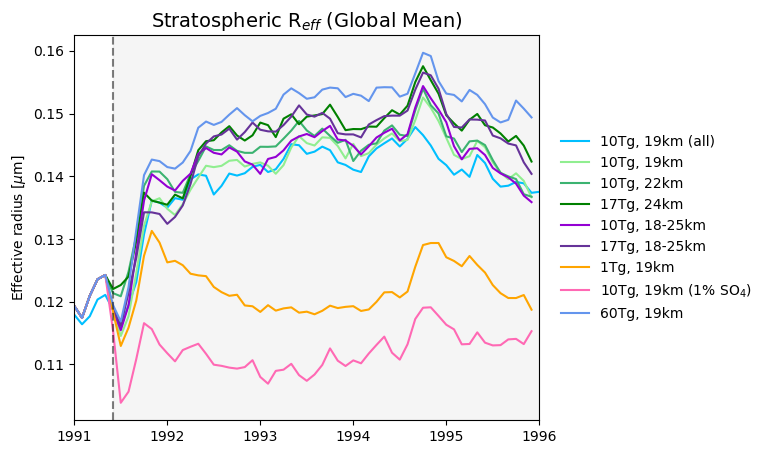

In [24]:
def to_float(x):
    return [t.year + (t.month-1)/12 for t in x.time.values]

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(to_float(SReff), SReff, color="deepskyblue", label="10Tg, 19km (all)")
ax.plot(to_float(SReff_19_c), SReff_19_c, color="lightgreen", label="10Tg, 19km")
ax.plot(to_float(SReff_22), SReff_22, color="mediumseagreen", label="10Tg, 22km")
ax.plot(to_float(SReff_24), SReff_24, color="green", label="17Tg, 24km") 
ax.plot(to_float(SReff_1825), SReff_1825, color="darkviolet", label="10Tg, 18-25km")
ax.plot(to_float(SReff_1825_17tg), SReff_1825_17tg, color="rebeccapurple", label="17Tg, 18-25km")
ax.plot(to_float(SReff_1tg), SReff_1tg, color="orange", label="1Tg, 19km")
ax.plot(to_float(SReff_1pr), SReff_1pr, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax.plot(to_float(SReff_60tg), SReff_60tg, color="cornflowerblue", label="60Tg, 19km")

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12   

ax.axvline(eruption_float, color='black', ls="--", alpha=0.5)
ax.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
ax.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
ax.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
ax.set_xlim(1991, 1996)

ax.set_ylabel("Effective radius [$\mu$m]")
ax.set_title("Stratospheric R$_{eff}$ (Global Mean)", fontsize=14)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

plt.show()

In [25]:
SReff_trop = compute_SReff_hybrid(ds_19, p_lev_upper=3.643466, p_lev_lower = p_lev_19, lat_range=(-20,20))
SReff_trop = SReff_trop.sel(time=slice("1991-01-01", "1996-01-01"))
SReff_19_c_trop = compute_SReff_hybrid(ds_19_c, p_lev_upper=3.643466, p_lev_lower = p_lev_19_c,lat_range=(-20,20))
SReff_22_trop = compute_SReff_hybrid(ds_22, p_lev_upper=3.643466,p_lev_lower=p_lev_22, lat_range=(-20,20))
SReff_24_trop = compute_SReff_hybrid(ds_24, p_lev_upper=3.643466,p_lev_lower=p_lev_24, lat_range=(-20,20))
SReff_1825_trop = compute_SReff_hybrid(ds_1825, p_lev_upper=3.643466,p_lev_lower=p_lev_1825, lat_range=(-20,20))
SReff_1825_17tg_trop = compute_SReff_hybrid(ds_1825_17tg, p_lev_upper=3.643466,p_lev_lower=p_lev_1825_17tg, lat_range=(-20,20))
SReff_1tg_trop = compute_SReff_hybrid(ds_1tg, p_lev_upper=3.643466,p_lev_lower=p_lev_1tg, lat_range=(-20,20))
SReff_1pr_trop = compute_SReff_hybrid(ds_1pr, p_lev_upper=3.643466,p_lev_lower=p_lev_1pr, lat_range=(-20,20))
SReff_60tg_trop = compute_SReff_hybrid(ds_60tg, p_lev_upper=3.643466,p_lev_lower=p_lev_60tg, lat_range=(-20,20))

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2559790/4212345847.py:11: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_ylabel("Effective radius [$\mu$m]")
/tmp/ipykernel_2559790/4212345847.py:23: SyntaxWarning: invalid escape sequence '\m'
  ax[1].set_ylabel("Effective radius [$\mu$m]")


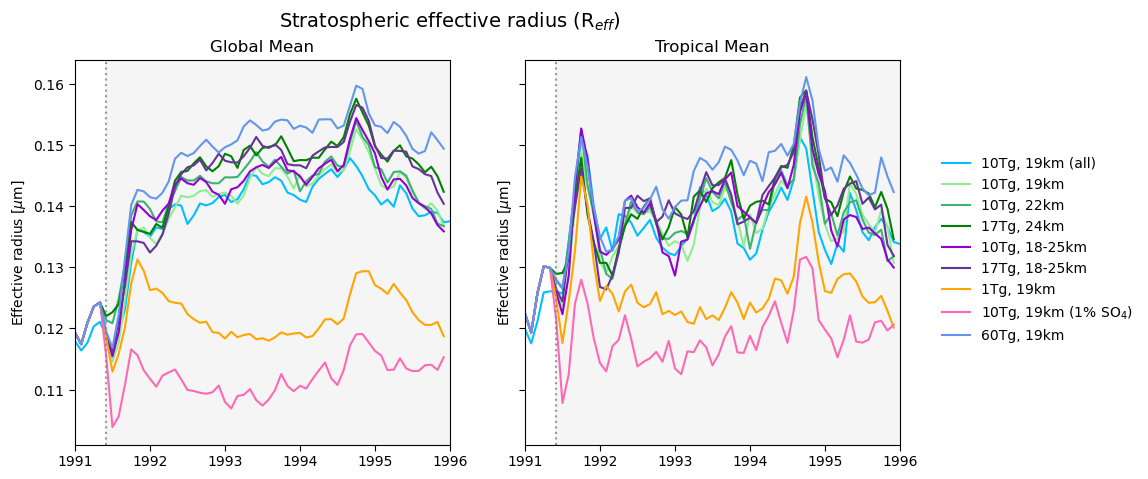

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].plot(to_float(SReff), SReff, color="deepskyblue", label="10Tg, 19km (all)")
ax[0].plot(to_float(SReff_19_c), SReff_19_c, color="lightgreen", label="10Tg, 19km")
ax[0].plot(to_float(SReff_22), SReff_22, color="mediumseagreen", label="10Tg, 22km")
ax[0].plot(to_float(SReff_24), SReff_24, color="green", label="17Tg, 24km") 
ax[0].plot(to_float(SReff_1825), SReff_1825, color="darkviolet", label="10Tg, 18-25km")
ax[0].plot(to_float(SReff_1825_17tg), SReff_1825_17tg, color="rebeccapurple", label="17Tg, 18-25km")
ax[0].plot(to_float(SReff_1tg), SReff_1tg, color="orange", label="1Tg, 19km")
ax[0].plot(to_float(SReff_1pr), SReff_1pr, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[0].plot(to_float(SReff_60tg), SReff_60tg, color="cornflowerblue", label="60Tg, 19km")
ax[0].set_ylabel("Effective radius [$\mu$m]")
ax[0].set_title("Global Mean", fontsize=12)

ax[1].plot(to_float(SReff_trop), SReff_trop, color="deepskyblue", label="10Tg, 19km (all)")
ax[1].plot(to_float(SReff_19_c_trop), SReff_19_c_trop, color="lightgreen", label="10Tg, 19km")
ax[1].plot(to_float(SReff_22_trop), SReff_22_trop, color="mediumseagreen", label="10Tg, 22km")
ax[1].plot(to_float(SReff_24_trop), SReff_24_trop, color="green", label="17Tg, 24km") 
ax[1].plot(to_float(SReff_1825_trop), SReff_1825_trop, color="darkviolet", label="10Tg, 18-25km")
ax[1].plot(to_float(SReff_1825_17tg_trop), SReff_1825_17tg_trop, color="rebeccapurple", label="17Tg, 18-25km")
ax[1].plot(to_float(SReff_1tg_trop), SReff_1tg_trop, color="orange", label="1Tg, 19km")
ax[1].plot(to_float(SReff_1pr_trop), SReff_1pr_trop, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[1].plot(to_float(SReff_60tg_trop), SReff_60tg_trop, color="cornflowerblue", label="60Tg, 19km")
ax[1].set_ylabel("Effective radius [$\mu$m]")
ax[1].set_title("Tropical Mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12   

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)


handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Stratospheric effective radius (R$_{eff}$)", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

In [27]:
SReff_trop_obs = compute_SReff_hybrid(ds_19, p_lev_upper=20, p_lev_lower = 50, lat_range=(-20,20))
SReff_trop_obs = SReff_trop_obs.sel(time=slice("1991-01-01", "1996-01-01"))
SReff_19_c_trop_obs = compute_SReff_hybrid(ds_19_c, p_lev_upper=20, p_lev_lower = 50, lat_range=(-20,20))
SReff_22_trop_obs = compute_SReff_hybrid(ds_22, p_lev_upper=20, p_lev_lower = 50, lat_range=(-20,20))
SReff_24_trop_obs = compute_SReff_hybrid(ds_24, p_lev_upper=20, p_lev_lower = 50, lat_range=(-20,20))
SReff_1825_trop_obs = compute_SReff_hybrid(ds_1825, p_lev_upper=20, p_lev_lower = 50, lat_range=(-20,20))
SReff_1825_17tg_trop_obs = compute_SReff_hybrid(ds_1825_17tg, p_lev_upper=20, p_lev_lower = 50, lat_range=(-20,20))
SReff_1tg_trop_obs = compute_SReff_hybrid(ds_1tg, p_lev_upper=20, p_lev_lower = 50, lat_range=(-20,20))
SReff_1pr_trop_obs = compute_SReff_hybrid(ds_1pr, p_lev_upper=20, p_lev_lower = 50, lat_range=(-20,20))
SReff_60tg_trop_obs = compute_SReff_hybrid(ds_60tg, p_lev_upper=20, p_lev_lower = 50, lat_range=(-20,20))

In [28]:
plev = 64
p_lev_l = 50
p_lev_u = 20
SReff_eq = compute_SReff_hybrid(ds_19, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(-5,5))
SReff_eq = SReff_eq.sel(time=slice("1991-01-01", "1996-01-01"))
SReff_19_c_eq = compute_SReff_hybrid(ds_19_c, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(-5,5))
SReff_22_eq = compute_SReff_hybrid(ds_22, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(-5,5))
SReff_24_eq = compute_SReff_hybrid(ds_24, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l,  lat_range=(-5,5))
SReff_1825_eq = compute_SReff_hybrid(ds_1825, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(-5,5))
SReff_1825_17tg_eq = compute_SReff_hybrid(ds_1825_17tg, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(-5,5))
SReff_1tg_eq = compute_SReff_hybrid(ds_1tg, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(-5,5))
SReff_1pr_eq = compute_SReff_hybrid(ds_1pr, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l,  lat_range=(-5,5))
SReff_60tg_eq = compute_SReff_hybrid(ds_60tg, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(-5,5))


<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2559790/3815965811.py:31: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("$\mu$m")
/tmp/ipykernel_2559790/3815965811.py:32: SyntaxWarning: invalid escape sequence '\c'
  ax.set_title("Stratospheric R$_{eff}$ (Equator: 5$^\circ$S-5$^\circ$N)")


Text(0.5, 1.0, 'Stratospheric R$_{eff}$ (Equator: 5$^\\circ$S-5$^\\circ$N)')

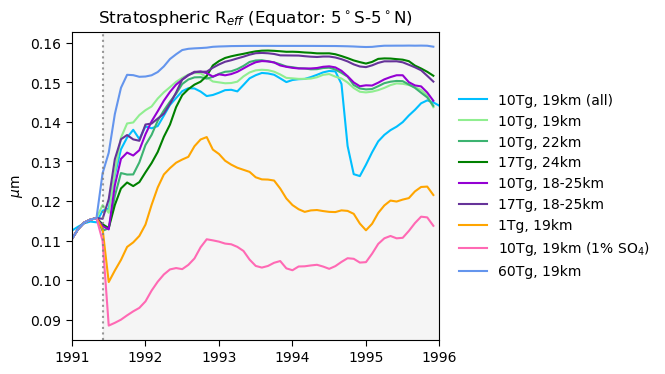

In [29]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(to_float(SReff_eq), SReff_eq, color="deepskyblue", label="10Tg, 19km (all)")
ax.plot(to_float(SReff_19_c_eq), SReff_19_c_eq, color="lightgreen", label="10Tg, 19km")
ax.plot(to_float(SReff_22_eq), SReff_22_eq, color="mediumseagreen", label="10Tg, 22km")
ax.plot(to_float(SReff_24_eq), SReff_24_eq, color="green", label="17Tg, 24km") 
ax.plot(to_float(SReff_1825_eq), SReff_1825_eq, color="darkviolet", label="10Tg, 18-25km")
ax.plot(to_float(SReff_1825_17tg_eq), SReff_1825_17tg_eq, color="rebeccapurple", label="17Tg, 18-25km")
ax.plot(to_float(SReff_1tg_eq), SReff_1tg_eq, color="orange", label="1Tg, 19km")
ax.plot(to_float(SReff_1pr_eq), SReff_1pr_eq, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax.plot(to_float(SReff_60tg_eq), SReff_60tg_eq, color="cornflowerblue", label="60Tg, 19km")

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12   

ax.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
ax.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
ax.tick_params(direction='out', length=4)

ax.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
ax.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
ax.set_xlim(1991, 1996)

fig.subplots_adjust(right=0.65)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
ax.set_ylabel("$\mu$m")
ax.set_title("Stratospheric R$_{eff}$ (Equator: 5$^\circ$S-5$^\circ$N)")


In [30]:
cm_to_mym = 10000
p_lev_l = 130
p_lev_u = 10
plev = 64
SReff_Laramie = compute_SReff_hybrid(ds_19, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(40,42), lon_range=(105, 106.5))
SReff_Laramie = SReff_Laramie.sel(time=slice("1991-01-01", "1996-01-01"))
SReff_19_c_Laramie = compute_SReff_hybrid(ds_19_c, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(40,42), lon_range=(105, 106.5))
SReff_22_Laramie = compute_SReff_hybrid(ds_22, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(40,42), lon_range=(105, 106.5))
SReff_24_Laramie = compute_SReff_hybrid(ds_24, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l,  lat_range=(40,42), lon_range=(105, 106.5))
SReff_1825_Laramie = compute_SReff_hybrid(ds_1825, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(40,42), lon_range=(105, 106.5))
SReff_1825_17tg_Laramie = compute_SReff_hybrid(ds_1825_17tg, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(40,42), lon_range=(105, 106.5))
SReff_1tg_Laramie = compute_SReff_hybrid(ds_1tg, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(40,42), lon_range=(105, 106.5))
SReff_1pr_Laramie = compute_SReff_hybrid(ds_1pr, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l,  lat_range=(40,42), lon_range=(105, 106.5))
SReff_60tg_Laramie = compute_SReff_hybrid(ds_60tg, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(40,42), lon_range=(105, 106.5))

<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2559790/1828647135.py:31: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("$\mu$m")


Text(0.5, 1.0, 'Stratospheric R$_{eff}$ (Laramie, lev ~64hPa)')

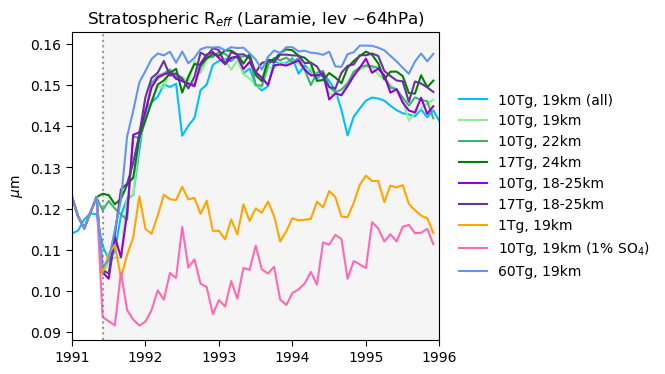

In [31]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(to_float(SReff_Laramie), SReff_Laramie, color="deepskyblue", label="10Tg, 19km (all)")
ax.plot(to_float(SReff_19_c_Laramie), SReff_19_c_Laramie, color="lightgreen", label="10Tg, 19km")
ax.plot(to_float(SReff_22_Laramie), SReff_22_Laramie, color="mediumseagreen", label="10Tg, 22km")
ax.plot(to_float(SReff_24_Laramie), SReff_24_Laramie, color="green", label="17Tg, 24km") 
ax.plot(to_float(SReff_1825_Laramie), SReff_1825_Laramie, color="darkviolet", label="10Tg, 18-25km")
ax.plot(to_float(SReff_1825_17tg_Laramie), SReff_1825_17tg_Laramie, color="rebeccapurple", label="17Tg, 18-25km")
ax.plot(to_float(SReff_1tg_Laramie), SReff_1tg_Laramie, color="orange", label="1Tg, 19km")
ax.plot(to_float(SReff_1pr_Laramie), SReff_1pr_Laramie, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax.plot(to_float(SReff_60tg_Laramie), SReff_60tg_Laramie, color="cornflowerblue", label="60Tg, 19km")

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12   

ax.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
ax.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
ax.tick_params(direction='out', length=4)

ax.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
ax.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
ax.set_xlim(1991, 1996)

fig.subplots_adjust(right=0.65)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
ax.set_ylabel("$\mu$m")
ax.set_title("Stratospheric R$_{eff}$ (Laramie, lev ~64hPa)")

## With Observations

In [32]:
path_obs = "/nird/datapeak/NS1004K/elihho/obs_pinatubo/dataset/Observation"
sageii_tropreff = pd.read_csv(f"{path_obs}/sageii_tropical_reff.txt", delim_whitespace=True, header=0,  index_col=0)
start = pd.Timestamp("1991-01-01")
months_sageii = [int(c) for c in sageii_tropreff.columns]
dates_sageii = [start + pd.DateOffset(months=m) for m in months_sageii]
sageii_tropreff.columns = dates_sageii

/tmp/ipykernel_2559790/1079825040.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  sageii_tropreff = pd.read_csv(f"{path_obs}/sageii_tropical_reff.txt", delim_whitespace=True, header=0,  index_col=0)


In [33]:
OPC_reff = pd.read_csv(f"{path_obs}/OPC_strat_reff.txt", delim_whitespace=True)
start_date = pd.Timestamp("1991-01-01")
OPC_reff['date'] = start_date + pd.to_timedelta(OPC_reff['Days_since_Jan_1991'], unit='D')

/tmp/ipykernel_2559790/238763274.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  OPC_reff = pd.read_csv(f"{path_obs}/OPC_strat_reff.txt", delim_whitespace=True)


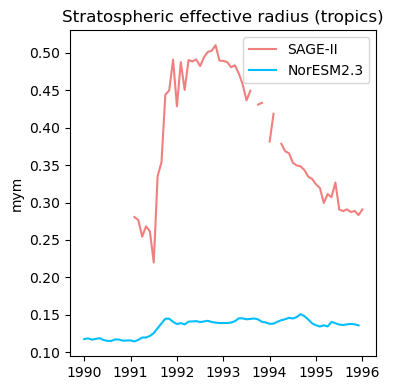

In [34]:
strat_reff_sageii = sageii_tropreff.loc["Strat_mean_sad_weighted"].astype(float)
cm_to_mym = 10000

SReff = ds_19["REFF_AERO"].where(ds_19["REFF_AERO"]["lev"] <= p_lev_19)
SReff_trop = SReff.sel(lat = slice(-20,20))
SReff_trop = SReff_trop.weighted(weighted_lat_19).mean(dim=["lat", "lon", "lev"]) * cm_to_mym
SReff_trop = SReff_trop.sel(time=slice("1990-01-01", "1995-12-31"))

obs_time_sageii = np.array([t.year + (t.month-1)/12 for t in strat_reff_sageii.index])
time_years = np.array([t.year + (t.month-1)/12 for t in SReff_trop.time.values])

plt.figure(figsize=(4, 4))
plt.plot(obs_time_sageii, strat_reff_sageii, color = "lightcoral", label = "SAGE-II")
plt.plot(time_years, SReff_trop, color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("mym")
plt.title("Stratospheric effective radius (tropics)")
plt.legend()
plt.tight_layout()

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2559790/3725965131.py:15: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_ylabel("Effective radius [$\mu$m]")
/tmp/ipykernel_2559790/3725965131.py:32: SyntaxWarning: invalid escape sequence '\m'
  ax[1].set_ylabel("Effective radius [$\mu$m]")


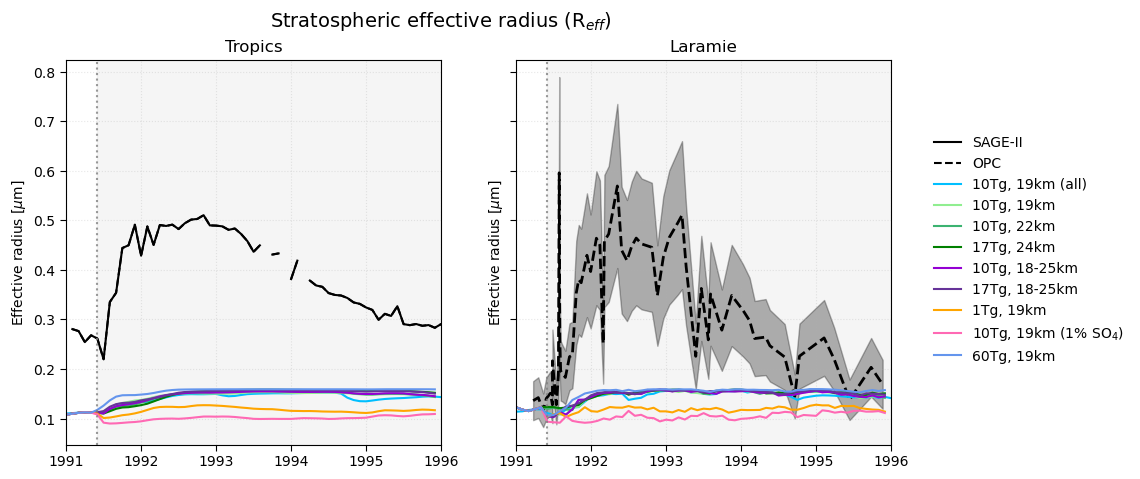

In [35]:
OPC_time = 1991 + (OPC_reff['Days_since_Jan_1991'] / 365.25)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].plot(obs_time_sageii, strat_reff_sageii, color = "black", label = "SAGE-II")
ax[0].plot(obs_time_sageii, strat_reff_sageii, color = "black", label = "OPC", ls="--")
ax[0].plot(to_float(SReff_trop_obs), SReff_trop_obs, color="deepskyblue", label="10Tg, 19km (all)")
ax[0].plot(to_float(SReff_19_c_trop_obs), SReff_19_c_trop_obs, color="lightgreen", label="10Tg, 19km")
ax[0].plot(to_float(SReff_22_trop_obs), SReff_22_trop_obs, color="mediumseagreen", label="10Tg, 22km")
ax[0].plot(to_float(SReff_24_trop_obs), SReff_24_trop_obs, color="green", label="17Tg, 24km") 
ax[0].plot(to_float(SReff_1825_trop_obs), SReff_1825_trop_obs, color="darkviolet", label="10Tg, 18-25km")
ax[0].plot(to_float(SReff_1825_17tg_trop_obs), SReff_1825_17tg_trop_obs, color="rebeccapurple", label="17Tg, 18-25km")
ax[0].plot(to_float(SReff_1tg_trop_obs), SReff_1tg_trop_obs, color="orange", label="1Tg, 19km")
ax[0].plot(to_float(SReff_1pr_trop_obs), SReff_1pr_trop_obs, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[0].plot(to_float(SReff_60tg_trop_obs), SReff_60tg_trop_obs, color="cornflowerblue", label="60Tg, 19km")
ax[0].set_ylabel("Effective radius [$\mu$m]")
ax[0].set_title("Tropics", fontsize=12)

ax[1].plot(OPC_time, OPC_reff['strat_reff'], color="black", label="OPC", lw=2, ls="--")
ax[1].fill_between(OPC_time, 
                 OPC_reff['strat_reff'] - OPC_reff['strat_reff_err'], 
                 OPC_reff['strat_reff'] + OPC_reff['strat_reff_err'], 
                 color="black", alpha=0.3)
ax[1].plot(to_float(SReff_Laramie), SReff_Laramie, color="deepskyblue", label="10Tg, 19km (all)")
ax[1].plot(to_float(SReff_19_c_Laramie), SReff_19_c_Laramie, color="lightgreen", label="10Tg, 19km")
ax[1].plot(to_float(SReff_22_Laramie), SReff_22_Laramie, color="mediumseagreen", label="10Tg, 22km")
ax[1].plot(to_float(SReff_24_Laramie), SReff_24_Laramie, color="green", label="17Tg, 24km") 
ax[1].plot(to_float(SReff_1825_Laramie), SReff_1825_Laramie, color="darkviolet", label="10Tg, 18-25km")
ax[1].plot(to_float(SReff_1825_17tg_Laramie), SReff_1825_17tg_Laramie, color="rebeccapurple", label="17Tg, 18-25km")
ax[1].plot(to_float(SReff_1tg_Laramie), SReff_1tg_Laramie, color="orange", label="1Tg, 19km")
ax[1].plot(to_float(SReff_1pr_Laramie), SReff_1pr_Laramie, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[1].plot(to_float(SReff_60tg_Laramie), SReff_60tg_Laramie, color="cornflowerblue", label="60Tg, 19km")
ax[1].set_ylabel("Effective radius [$\mu$m]")
ax[1].set_title("Laramie", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12   

for i, a in enumerate(ax):
    a.grid(True, alpha=0.3, linestyle=':')
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)


handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Stratospheric effective radius (R$_{eff}$)", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

## Aerosol microphysics

<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2559790/3073481761.py:22: SyntaxWarning: invalid escape sequence '\m'
  axes[i].set_ylabel("[$\mu$m]")


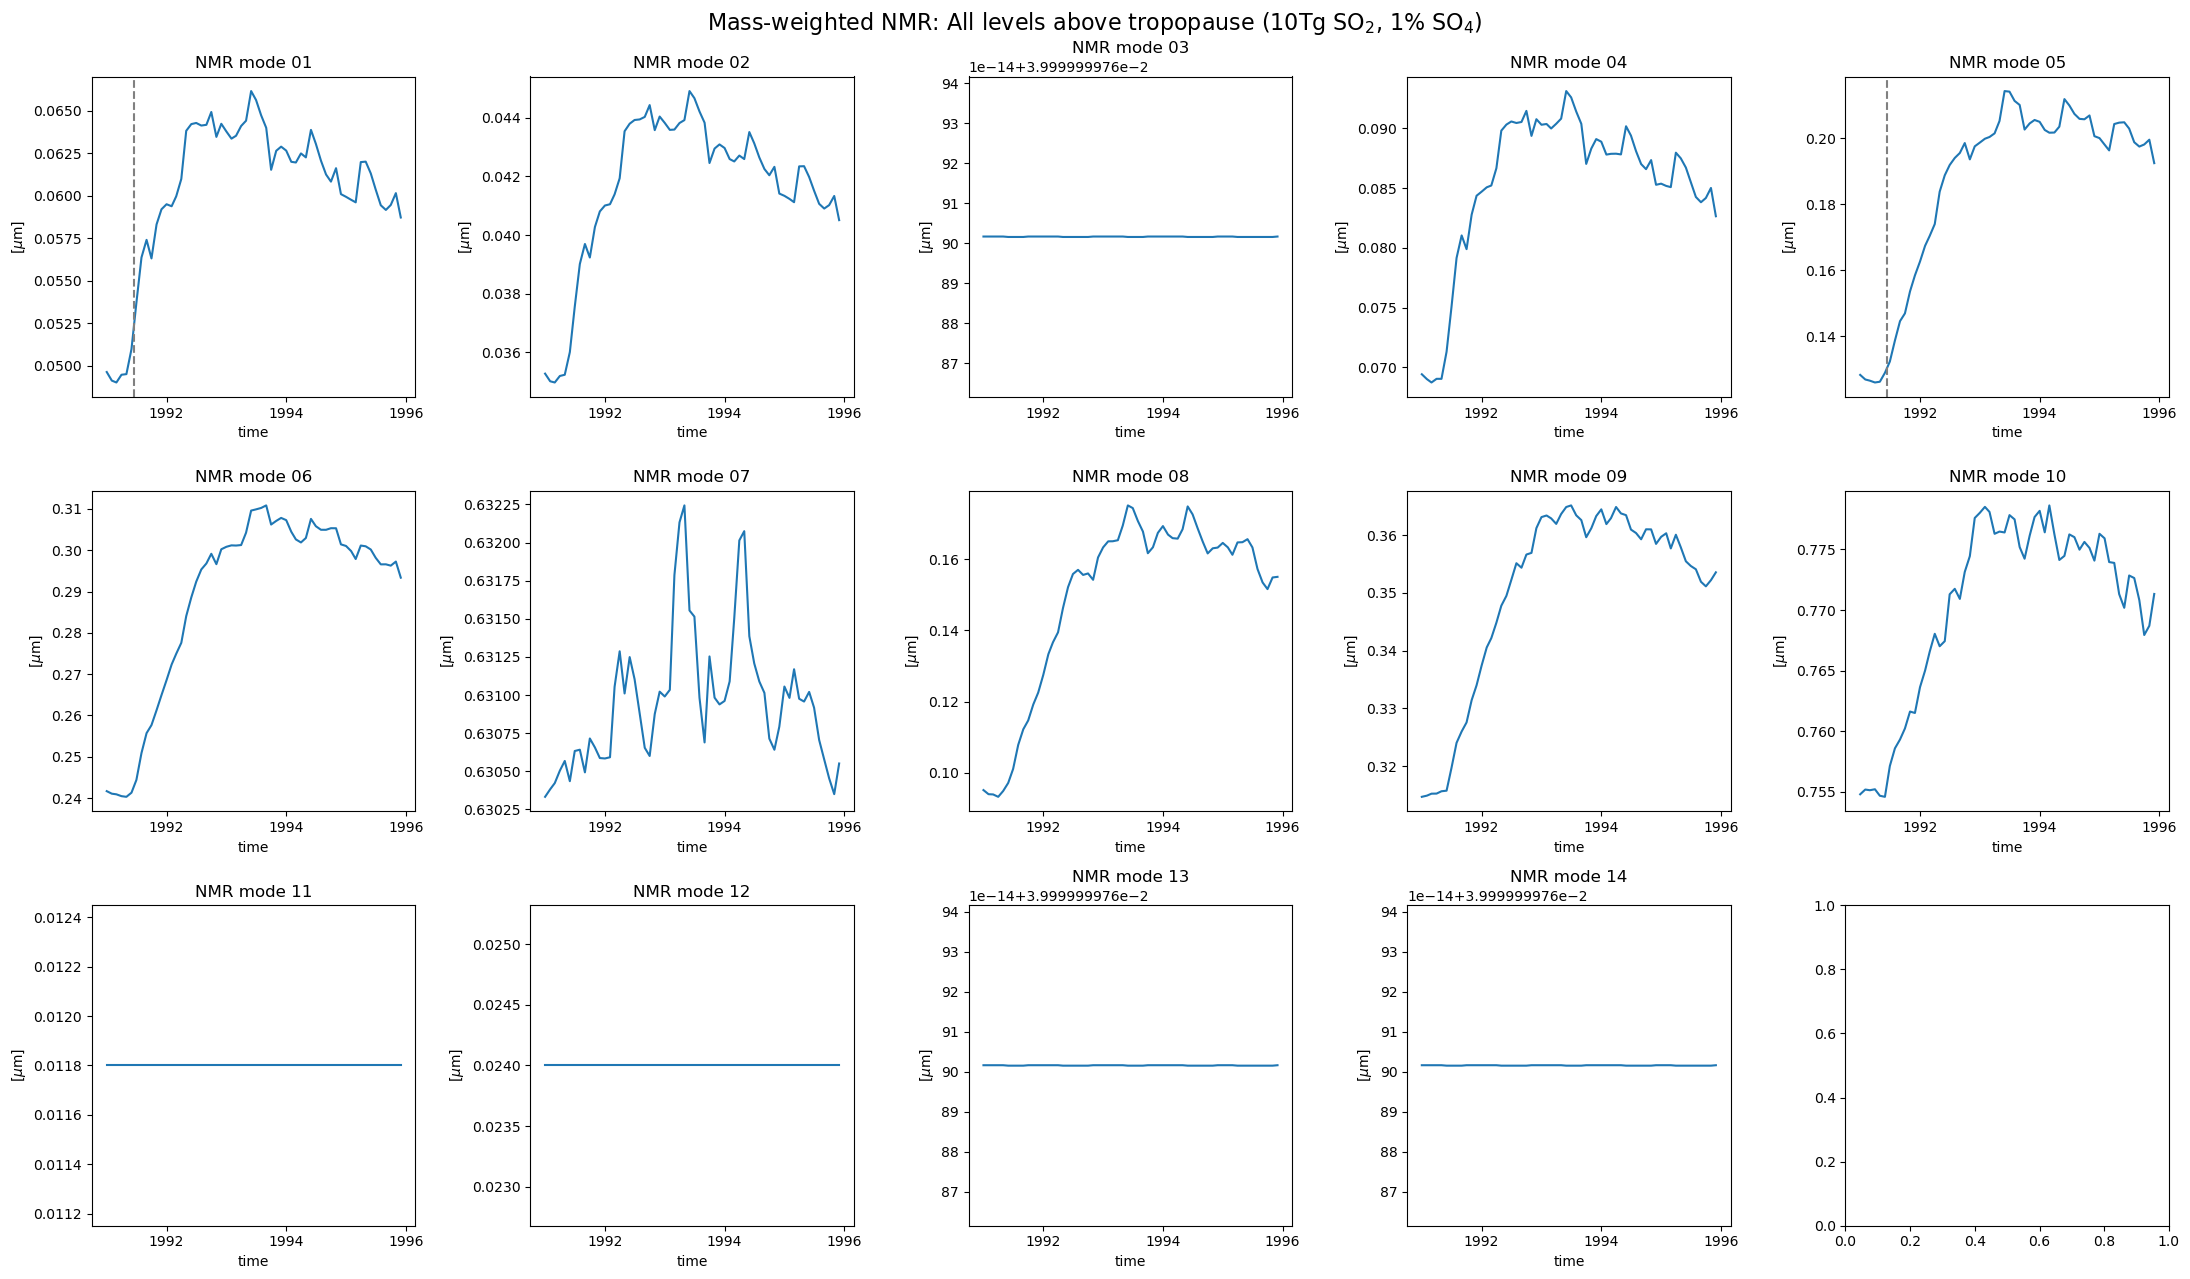

In [36]:
# vars to use: NMR, SIGMA, NCONC, VCONC, NNAT_
import nc_time_axis # Sørger for at matplotlib skjønner DatetimeNoLeap

lev_diff = np.abs(np.gradient(ds_1pr.lev.values))
weights_lev = xr.DataArray(lev_diff, coords={'lev': ds_1pr.lev}, dims=['lev'])

total_weight = weights_lev * weighted_lat_1pr
m_to_mym = cm_to_mym*100
mode_list = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12", "13", "14"]

fig, axes = plt.subplots(3, 5, figsize=(22, 13), sharex=False, sharey=False)
axes = axes.flatten()

for i, m in enumerate(mode_list):
    nmr_raw = ds_1pr[f"NMR{m}"]
    nmr_strat = nmr_raw.where(nmr_raw.lev <= p_lev_1pr)
    
    nmr_ts = nmr_strat.weighted(total_weight).mean(dim=["lat", "lon", "lev"]) * m_to_mym
    
    nmr_ts.plot(ax=axes[i]) 
    
    axes[i].set_ylabel("[$\mu$m]")
    axes[i].set_title(f"NMR mode {m}")

    if m in ["01", "05"]:
        t1line = cftime.DatetimeNoLeap(1991, 6, 15)
        axes[i].axvline(t1line, color="gray", linestyle="--")

for j in range(len(mode_list), 12):
    fig.delaxes(axes[j])

plt.suptitle("Mass-weighted NMR: All levels above tropopause (10Tg SO$_2$, 1% SO$_4$)", fontsize=16)
plt.tight_layout()
plt.show()
plt.show()

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2559790/323609567.py:18: SyntaxWarning: invalid escape sequence '\m'
  axes[i].set_ylabel("[$\mu$m]")


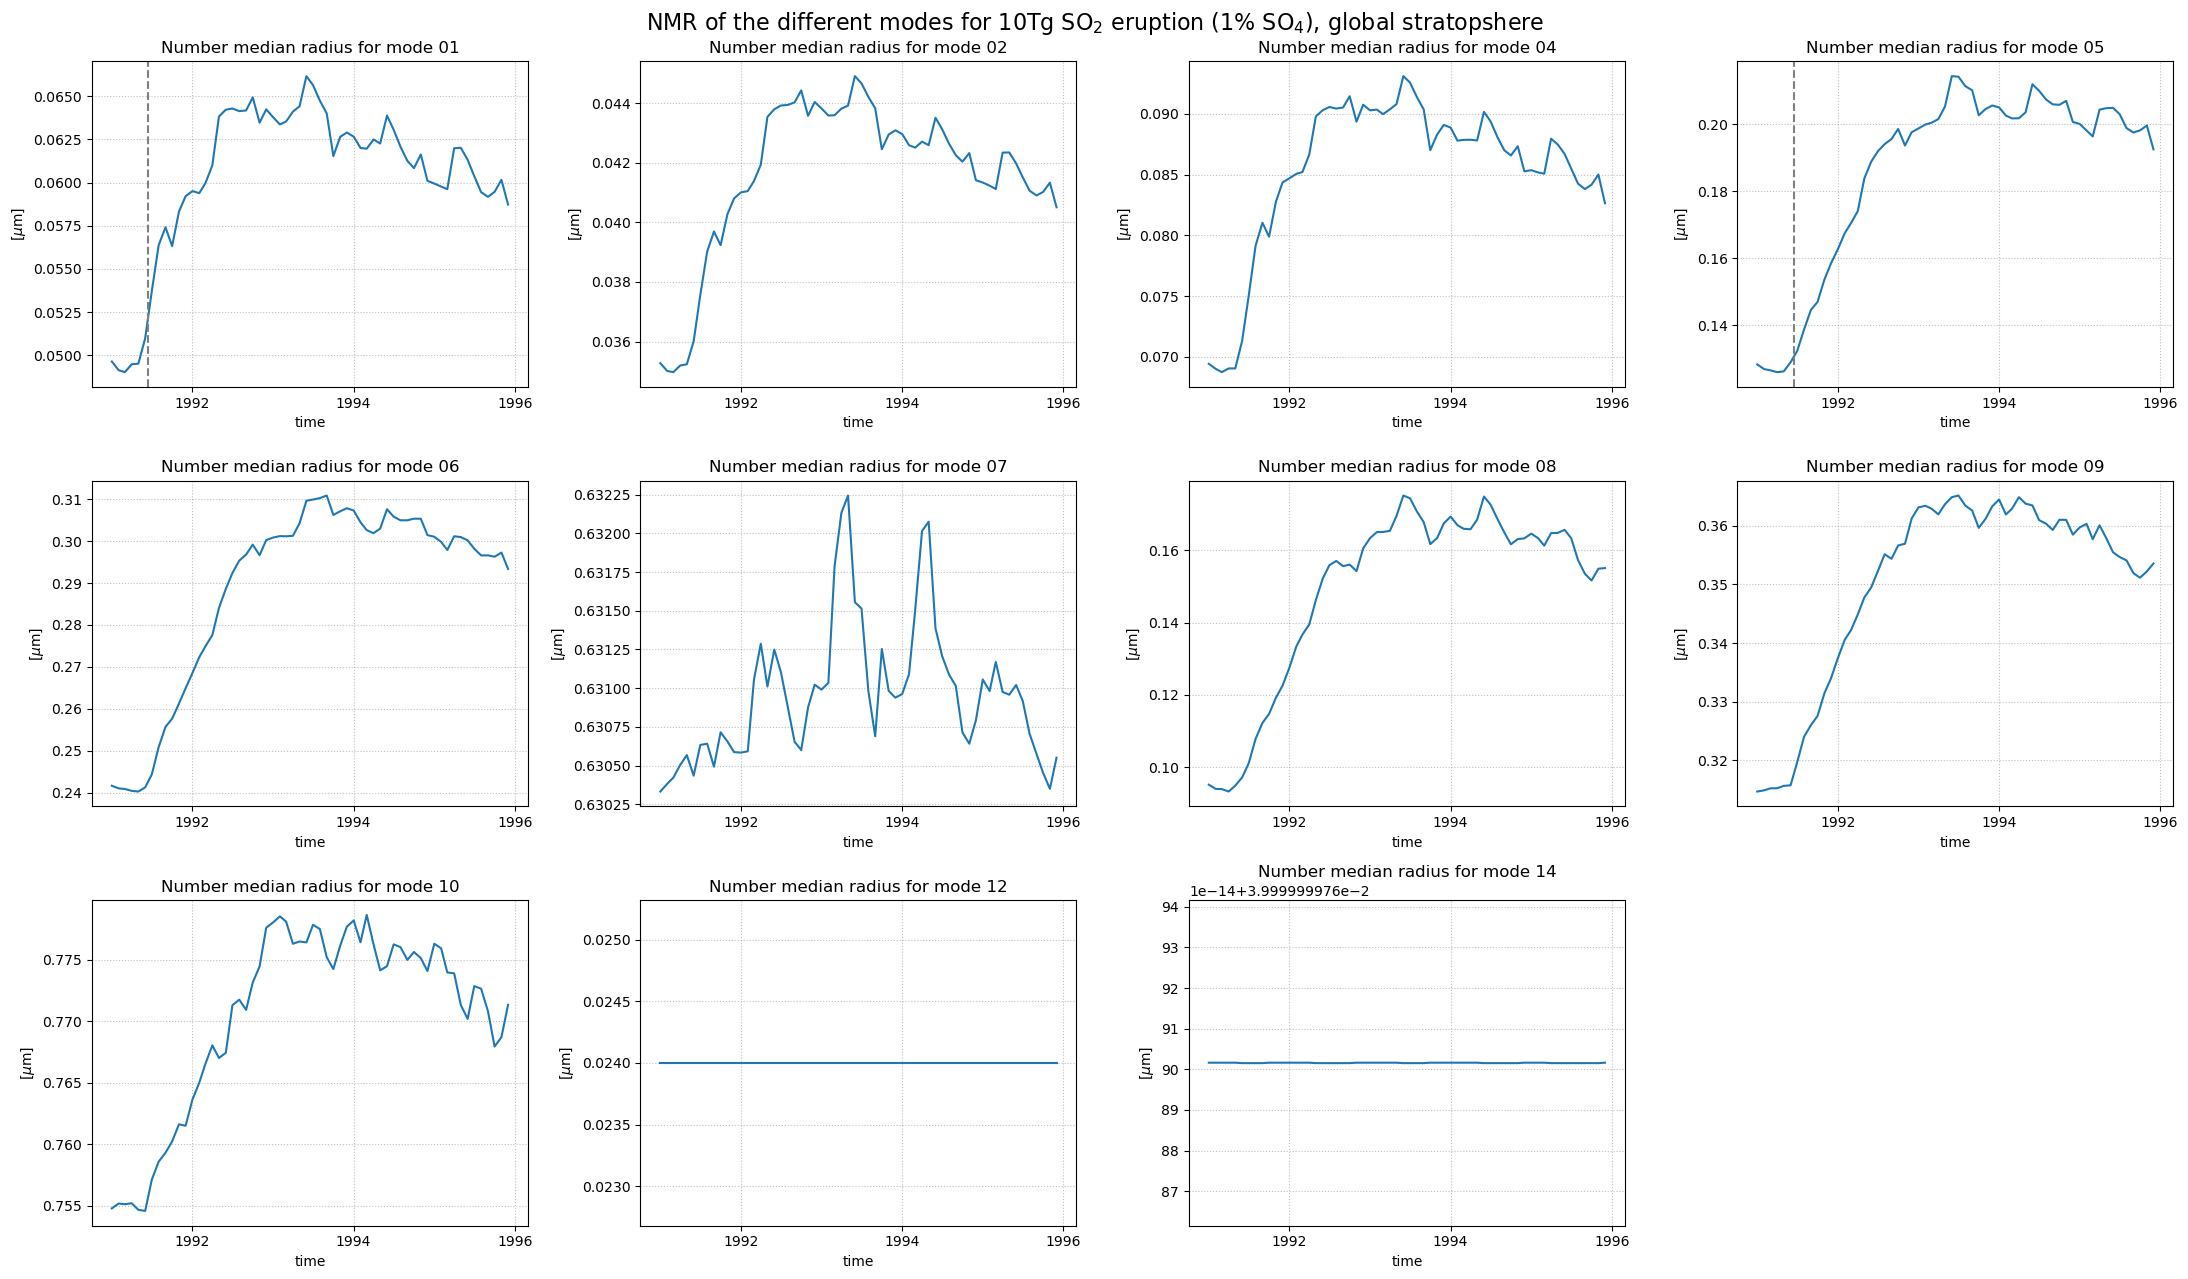

In [37]:
lev_diff = np.abs(np.gradient(ds_1pr.lev.values))
weights_lev = xr.DataArray(lev_diff, coords={'lev': ds_1pr.lev}, dims=['lev'])
total_weight = weights_lev * weighted_lat_1pr

modes = ["01", "02", "04", "05", "06", "07", "08", "09", "10", "12", "14"]
m_to_mym = cm_to_mym*100

fig, axes = plt.subplots(3, 4, figsize=(22, 13), sharex=False, sharey=False)
axes = axes.flatten() 

for i, m in enumerate(modes):
    nmr = ds_1pr[f"NMR{m}"].where(ds_1pr[f"NMR{m}"]["lev"] <= p_lev_1pr)
    
    nmr = nmr.weighted(total_weight).mean(dim=["lat","lon","lev"])*m_to_mym
    
    nmr.plot(ax=axes[i])
    
    axes[i].set_ylabel("[$\mu$m]")
    axes[i].set_title(f"Number median radius for mode {m}")
    axes[i].grid(color = "gray", alpha=0.5, linestyle=":")
    
    if m in ["01","05"]:
        t1line = cftime.DatetimeNoLeap(1991, 6, 15)
        axes[i].axvline(t1line, color="gray", linestyle="--")

for j in range(i+1, 3*4):
    fig.delaxes(axes[j])

plt.suptitle("NMR of the different modes for 10Tg SO$_2$ eruption (1% SO$_4$), global stratopshere", fontsize=16)
plt.tight_layout()
plt.show()

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2559790/1683781982.py:18: SyntaxWarning: invalid escape sequence '\m'
  axes[i].set_ylabel("[$\mu$m]")


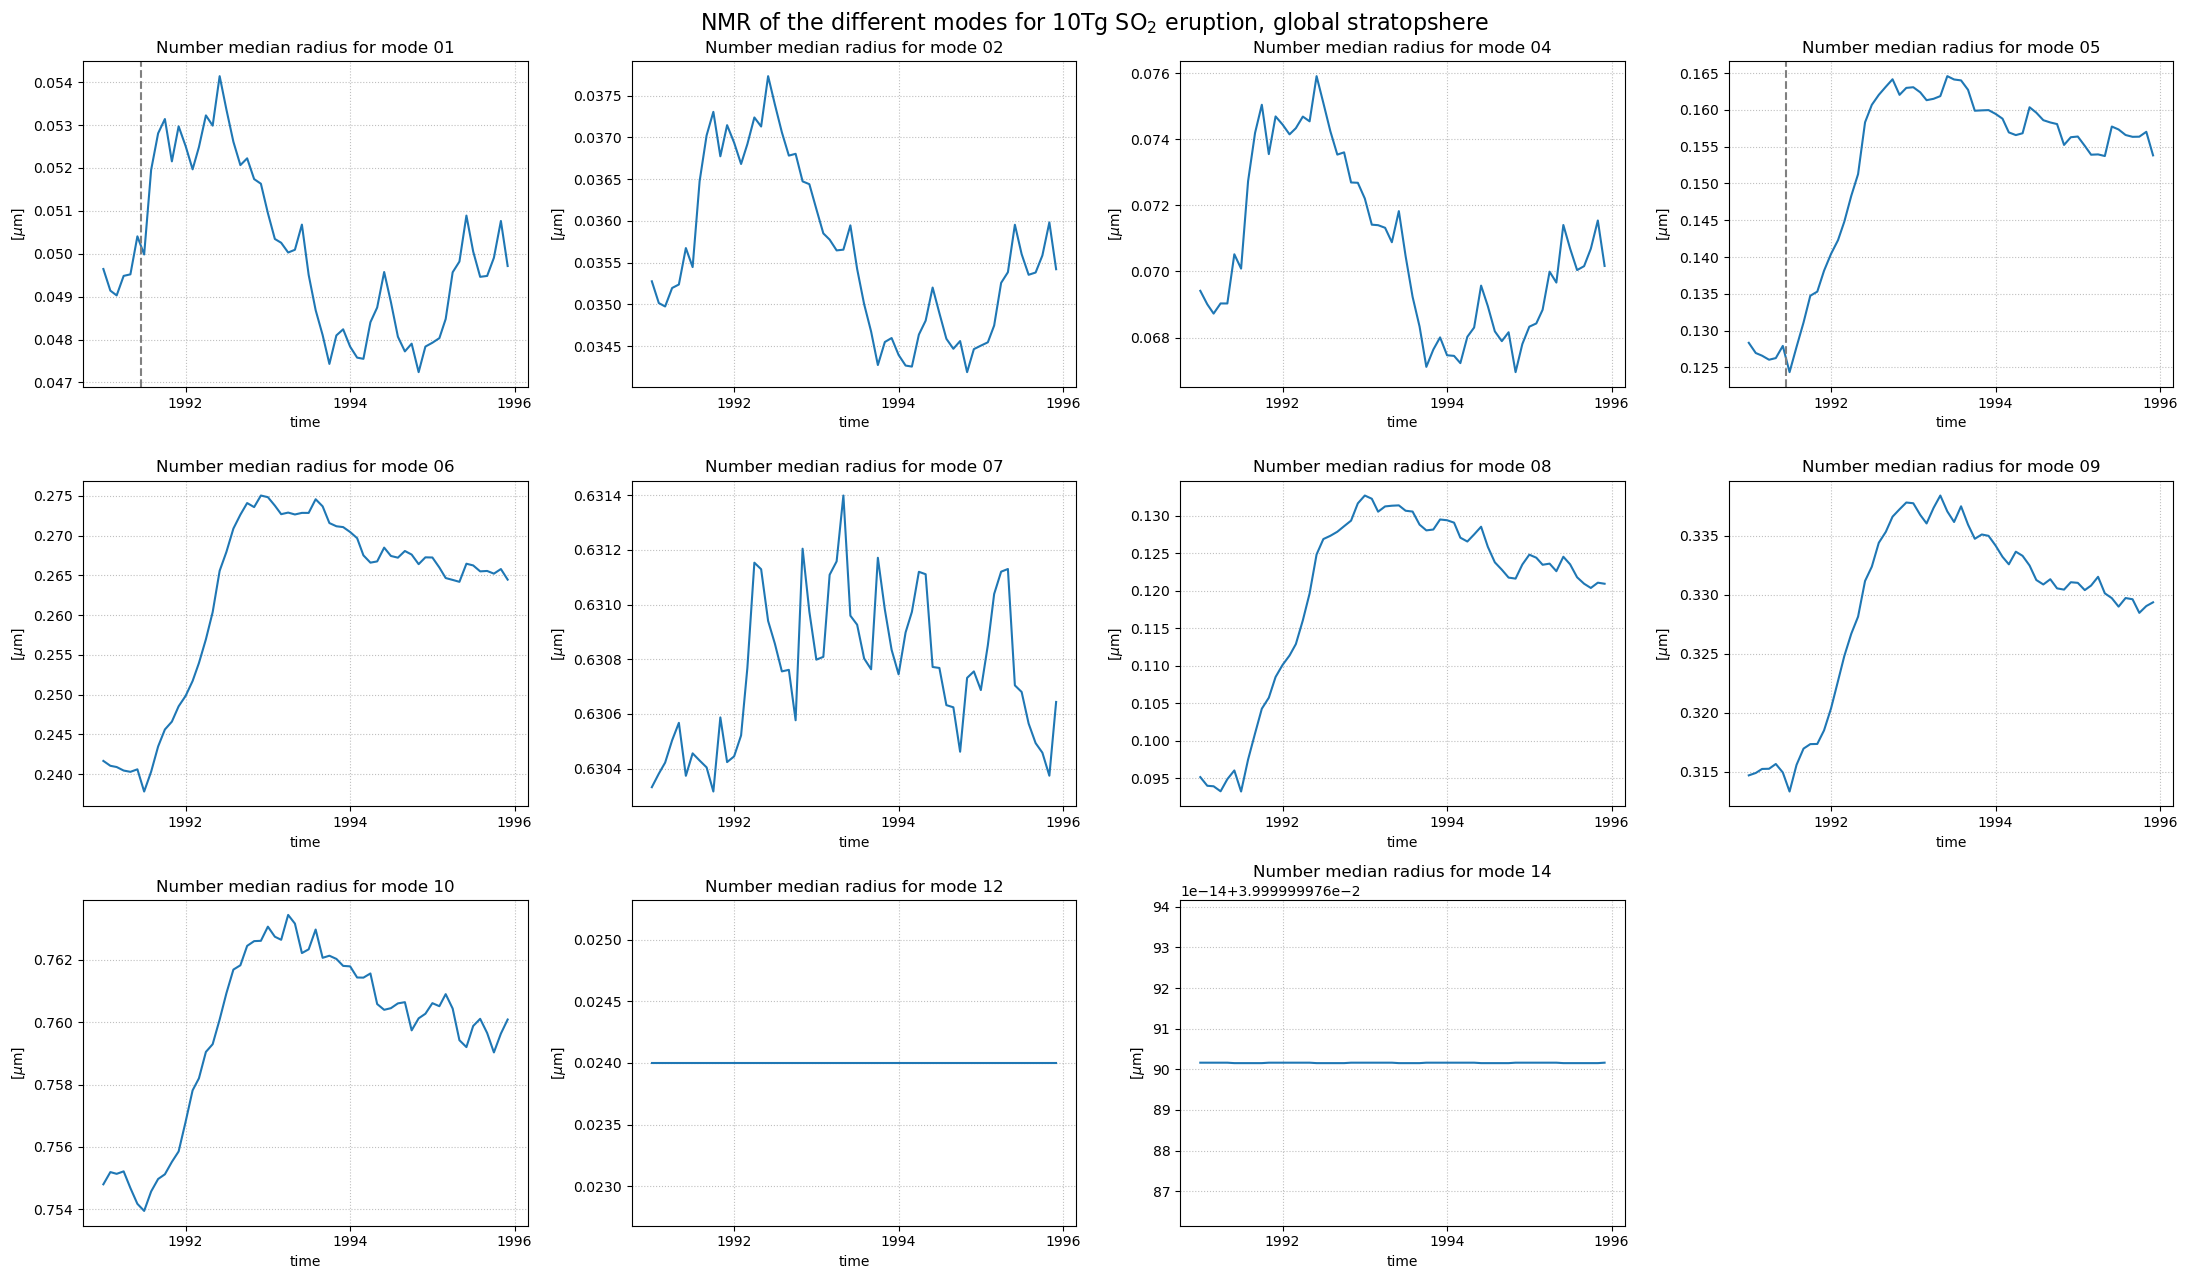

In [38]:
lev_diff = np.abs(np.gradient(ds_19_c.lev.values))
weights_lev = xr.DataArray(lev_diff, coords={'lev': ds_19_c.lev}, dims=['lev'])
total_weight = weights_lev * weighted_lat_19_c

modes = ["01", "02", "04", "05", "06", "07", "08", "09", "10", "12", "14"]
m_to_mym = cm_to_mym*100

fig, axes = plt.subplots(3, 4, figsize=(22, 13), sharex=False, sharey=False)
axes = axes.flatten() 

for i, m in enumerate(modes):
    nmr = ds_19_c[f"NMR{m}"].where(ds_19_c[f"NMR{m}"]["lev"] <= p_lev_19_c)
    
    nmr = nmr.weighted(total_weight).mean(dim=["lat","lon","lev"])*m_to_mym
    
    nmr.plot(ax=axes[i])
    
    axes[i].set_ylabel("[$\mu$m]")
    axes[i].set_title(f"Number median radius for mode {m}")
    axes[i].grid(color = "gray", alpha=0.5, linestyle=":")
    
    if m in ["01","05"]:
        t1line = cftime.DatetimeNoLeap(1991, 6, 15)
        axes[i].axvline(t1line, color="gray", linestyle="--")

for j in range(i+1, 3*4):
    fig.delaxes(axes[j])

plt.suptitle("NMR of the different modes for 10Tg SO$_2$ eruption, global stratopshere", fontsize=16)
plt.tight_layout()
plt.show()

In [39]:
ds_19_c["NMR01"]

<xarray.DataArray 'NMR01' (time: 60, lev: 32, lat: 192, lon: 288)> Size: 425MB
dask.array<concatenate, shape=(60, 32, 192, 288), dtype=float32, chunksize=(1, 32, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * time     (time) object 480B 1991-01-01 00:00:00 ... 1995-12-01 00:00:00
Attributes:
    mdims:         1
    units:         m
    long_name:     number median radius mode 01
    cell_methods:  time: mean

<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2559790/927223702.py:35: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("[$\mu$m]" if ax in axs[:, 0] else "")


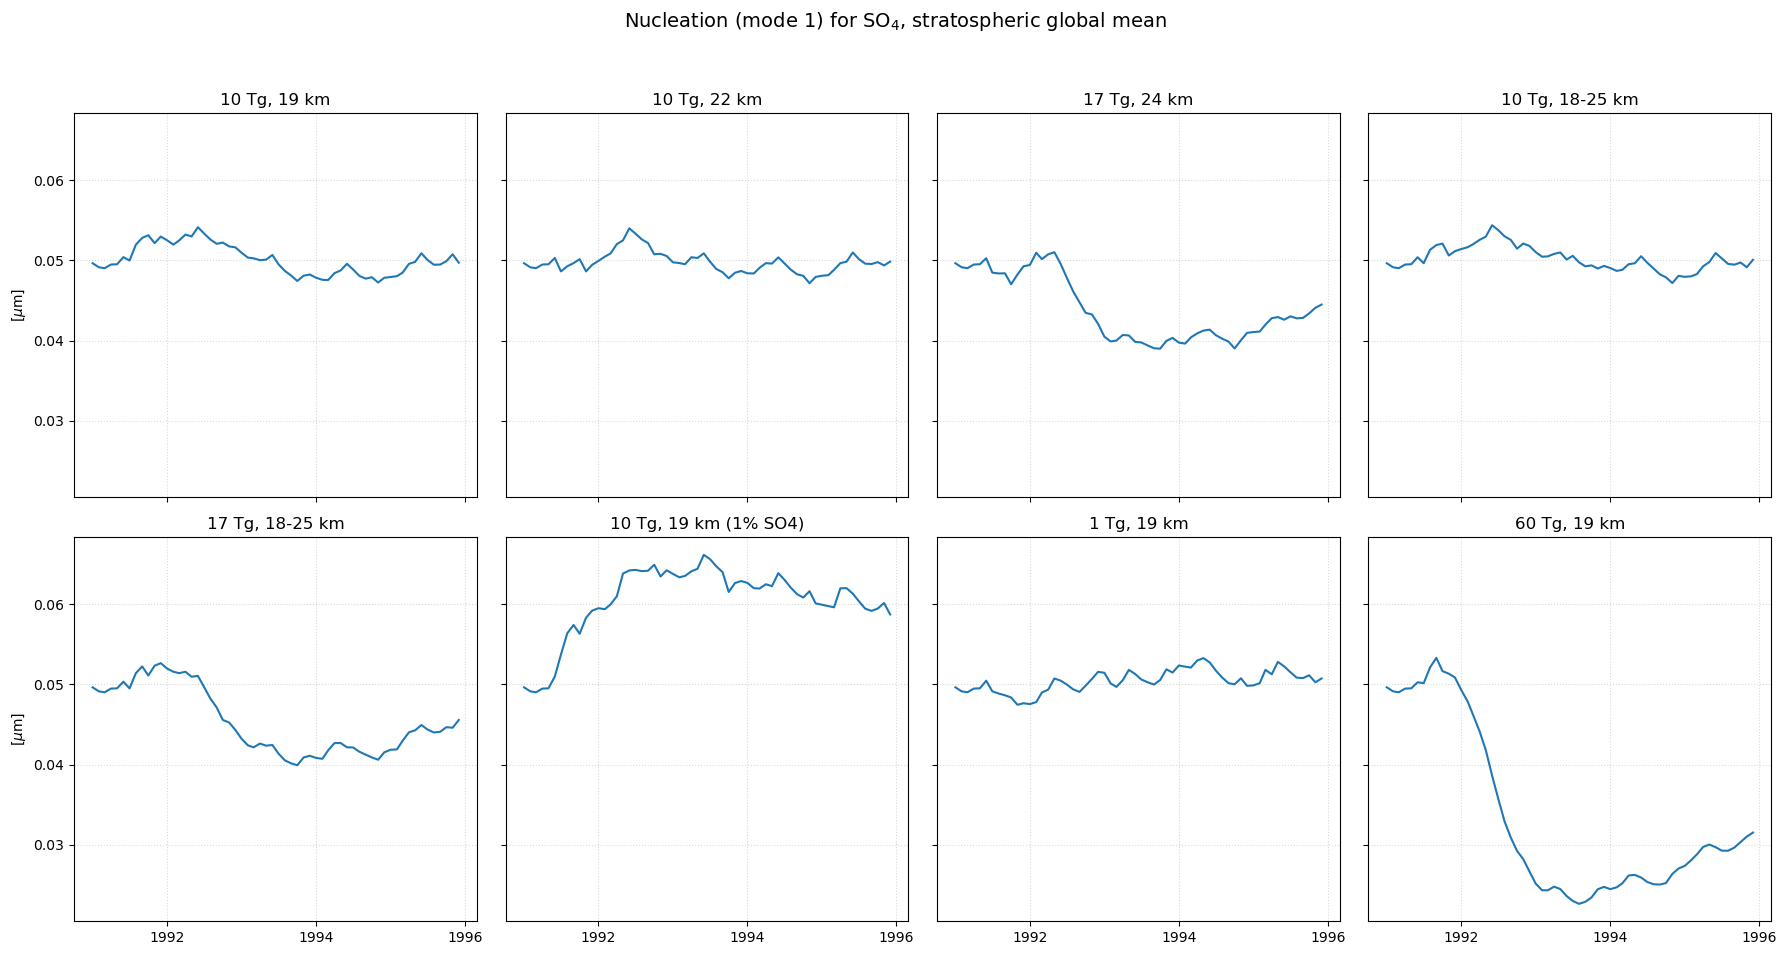

In [40]:
so4_modes = ["01", "05"]
ds = [ds_19_c, ds_22, ds_24, 
      ds_1825, ds_1825_17tg, ds_1pr, 
      ds_1tg, ds_60tg]
levels = [p_lev_19_c, p_lev_22, p_lev_24, 
          p_lev_1825, p_lev_1825_17tg, p_lev_1pr,
          p_lev_1tg, p_lev_60tg]
weights = [weighted_lat_19_c, weighted_lat_22, weighted_lat_24,
           weighted_lat_1825, weighted_lat_1825_17tg, weighted_lat_1pr,
           weighted_lat_1tg, weighted_lat_60tg]

titles = ["10 Tg, 19 km", 
          "10 Tg, 22 km", 
          "17 Tg, 24 km", 
          "10 Tg, 18-25 km", 
          "17 Tg, 18-25 km", 
          "10 Tg, 19 km (1% SO4)", 
          "1 Tg, 19 km", 
          "60 Tg, 19 km"]

fig, axs = plt.subplots(2, 4, figsize=(18, 10), sharex=True, sharey=True)

for ax, current_ds, w, p, title in zip(axs.flat, ds, weights, levels, titles):
    lev_vals = current_ds.lev.values
    lev_diff = np.abs(np.gradient(lev_vals))
    wl = xr.DataArray(lev_diff, coords={'lev': current_ds.lev}, dims=['lev'])
    
    nmr_raw = current_ds["NMR01"].where(current_ds["lev"] <= p)
    
    nmr_h = nmr_raw.weighted(w).mean(dim=["lat", "lon"])
    nmr_final = nmr_h.weighted(wl).mean(dim="lev") * m_to_mym
    nmr_final.plot(ax=ax)
    
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("[$\mu$m]" if ax in axs[:, 0] else "")
    ax.set_xlabel("") 
    ax.grid(color="gray", alpha=0.3, linestyle=":")

plt.suptitle("Nucleation (mode 1) for SO$_4$, stratospheric global mean", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2559790/3519488015.py:35: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("[$\mu$m]" if ax in axs[:, 0] else "")


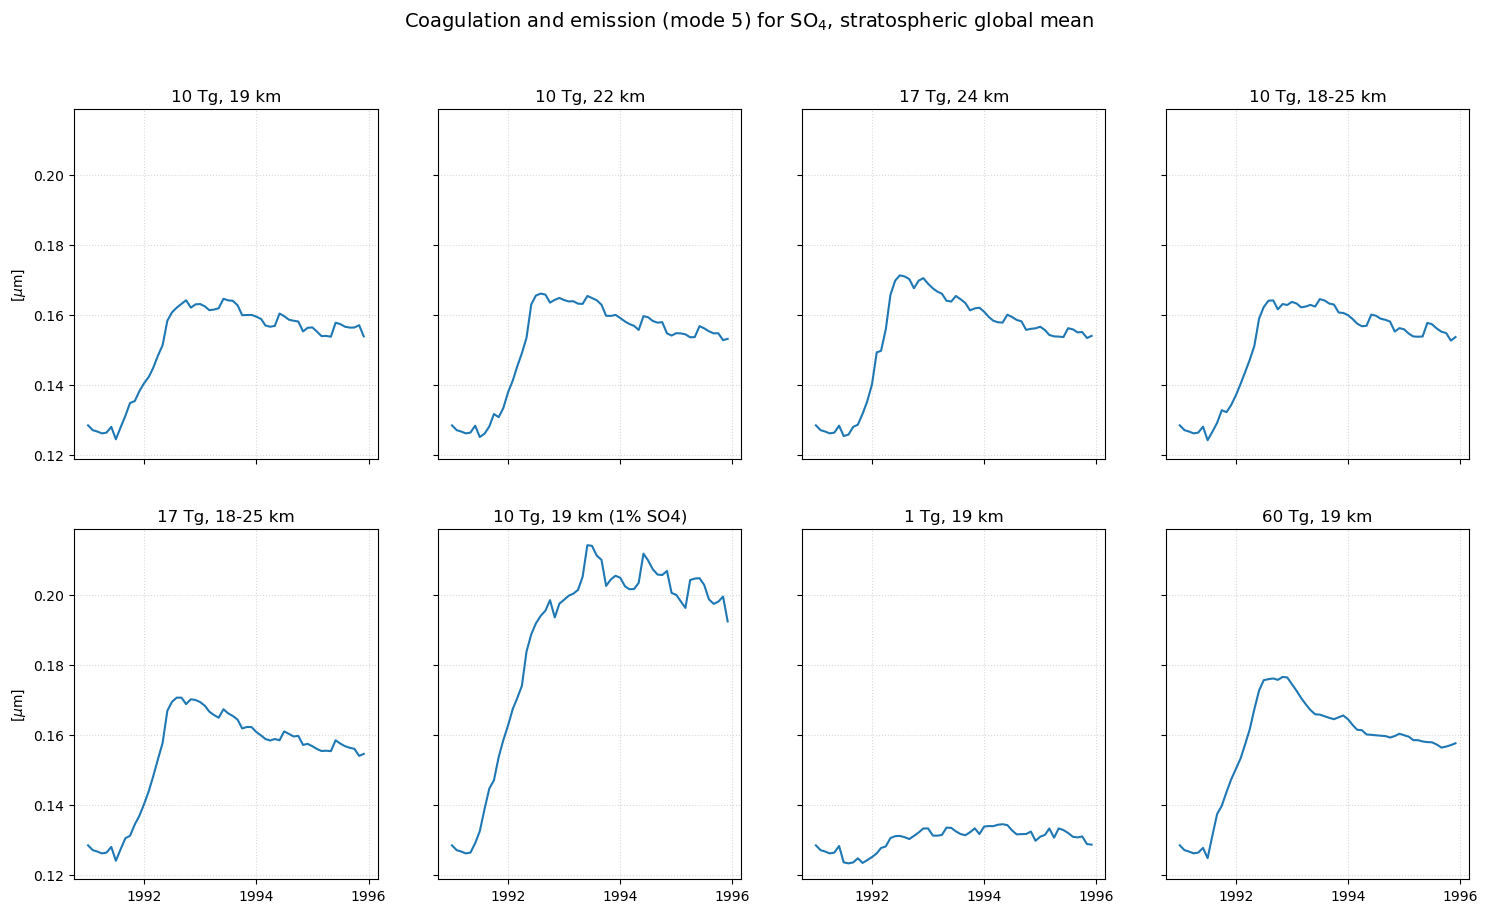

In [41]:
so4_modes = ["01", "05"]
ds = [ds_19_c, ds_22, ds_24, 
      ds_1825, ds_1825_17tg, ds_1pr, 
      ds_1tg, ds_60tg]
levels = [p_lev_19_c, p_lev_22, p_lev_24, 
          p_lev_1825, p_lev_1825_17tg, p_lev_1pr,
          p_lev_1tg, p_lev_60tg]
weights = [weighted_lat_19_c, weighted_lat_22, weighted_lat_24,
           weighted_lat_1825, weighted_lat_1825_17tg, weighted_lat_1pr,
           weighted_lat_1tg, weighted_lat_60tg]

titles = ["10 Tg, 19 km", 
          "10 Tg, 22 km", 
          "17 Tg, 24 km", 
          "10 Tg, 18-25 km", 
          "17 Tg, 18-25 km", 
          "10 Tg, 19 km (1% SO4)", 
          "1 Tg, 19 km", 
          "60 Tg, 19 km"]

fig, axs = plt.subplots(2, 4, figsize=(18, 10), sharex=True, sharey=True)

for ax, current_ds, w, p, title in zip(axs.flat, ds, weights, levels, titles):
    lev_vals = current_ds.lev.values
    lev_diff = np.abs(np.gradient(lev_vals))
    wl = xr.DataArray(lev_diff, coords={'lev': current_ds.lev}, dims=['lev'])
    
    nmr_raw = current_ds["NMR05"].where(current_ds["lev"] <= p)
    
    nmr_h = nmr_raw.weighted(w).mean(dim=["lat", "lon"])
    nmr_final = nmr_h.weighted(wl).mean(dim="lev") * m_to_mym
    nmr_final.plot(ax=ax)
    
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("[$\mu$m]" if ax in axs[:, 0] else "")
    ax.set_xlabel("") 
    ax.grid(color="gray", alpha=0.3, linestyle=":")

plt.suptitle("Coagulation and emission (mode 5) for SO$_4$, stratospheric global mean", fontsize=14)
plt.show()

<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2559790/498066631.py:45: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel(f"Radius [$\mu$m]", fontsize=12)


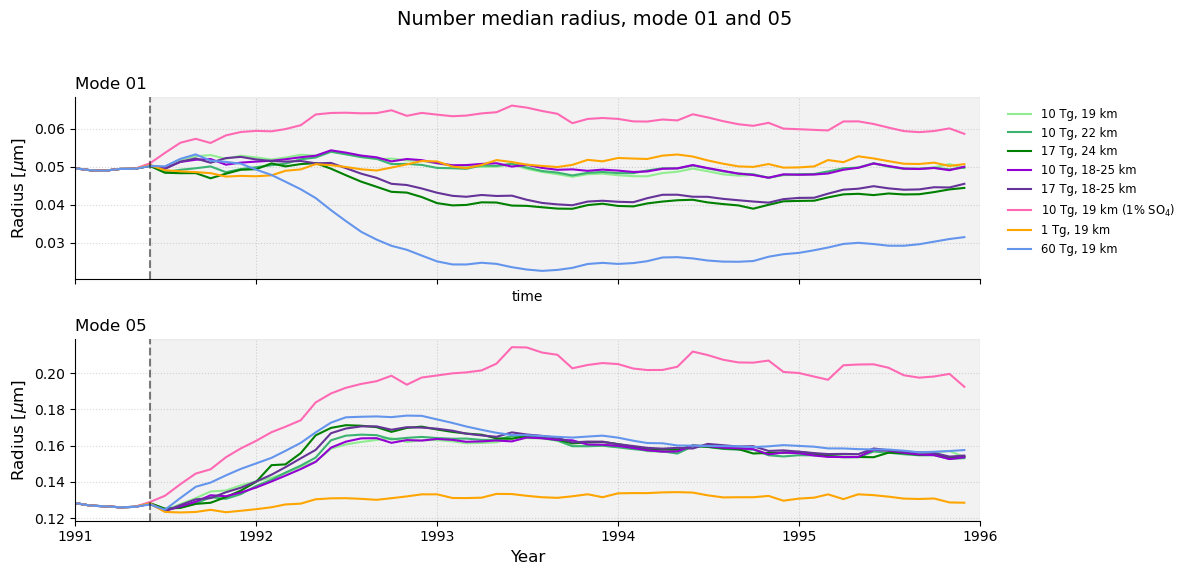

In [42]:
so4_modes = ["01", "05"]
datasets = [ds_19_c, ds_22, ds_24, 
            ds_1825, ds_1825_17tg, ds_1pr, 
            ds_1tg, ds_60tg]

levels = [p_lev_19_c, p_lev_22, p_lev_24, 
          p_lev_1825, p_lev_1825_17tg, p_lev_1pr, 
          p_lev_1tg, p_lev_60tg]

weights = [weighted_lat_19_c, weighted_lat_22, weighted_lat_24, 
           weighted_lat_1825, weighted_lat_1825_17tg, weighted_lat_1pr, 
           weighted_lat_1tg, weighted_lat_60tg]

labels = ["10 Tg, 19 km", 
          "10 Tg, 22 km", 
          "17 Tg, 24 km", 
          "10 Tg, 18-25 km", 
          "17 Tg, 18-25 km", 
          "10 Tg, 19 km (1% SO$_4$)", 
          "1 Tg, 19 km", 
          "60 Tg, 19 km"]

colors =["lightgreen", "mediumseagreen", "green", "darkviolet", "rebeccapurple", "hotpink", "orange", "cornflowerblue"]

eruption_date = cftime.DatetimeNoLeap(1991, 6, 1)
end_date = cftime.DatetimeNoLeap(1996, 1, 1)

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for i, mode in enumerate(so4_modes):
    ax = axs[i]
    for d, w, p, label, color in zip(datasets, weights, levels, labels, colors):
        var_name = f"NMR{mode}"
        
        lev_vals = d.lev.values
        lev_diff = np.abs(np.gradient(lev_vals))
        wl = xr.DataArray(lev_diff, coords={'lev': d.lev}, dims=['lev'])
        
        nmr = d[var_name].where(d["lev"] <= p)
        nmr_h = nmr.weighted(w).mean(dim=["lat", "lon"])
        nmr_final = nmr_h.weighted(wl).mean(dim="lev") * m_to_mym
        
        nmr_final.plot(ax=ax, color=color, label=label, add_legend=False)
    
    ax.set_ylabel(f"Radius [$\mu$m]", fontsize=12)
    ax.set_title(f"Mode {mode}", loc='left')
    ax.grid(True, color="gray", alpha=0.3, linestyle=":")
    
    ax.axvline(eruption_date, color='black', ls="--", alpha=0.5)
    ax.axvspan(eruption_date, end_date, color='gray', alpha=0.1, zorder=0)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    if i == 0:
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize='small', frameon=False)

years = np.arange(1991, 1997)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
ax.set_xticks(year_ticks)
ax.set_xticklabels([str(y) for y in years])
ax.set_xlabel("Year", fontsize=12)

ax.set_xlim(cftime.DatetimeNoLeap(1991, 1, 1), cftime.DatetimeNoLeap(1996, 1, 1))
plt.suptitle("Number median radius, mode 01 and 05", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

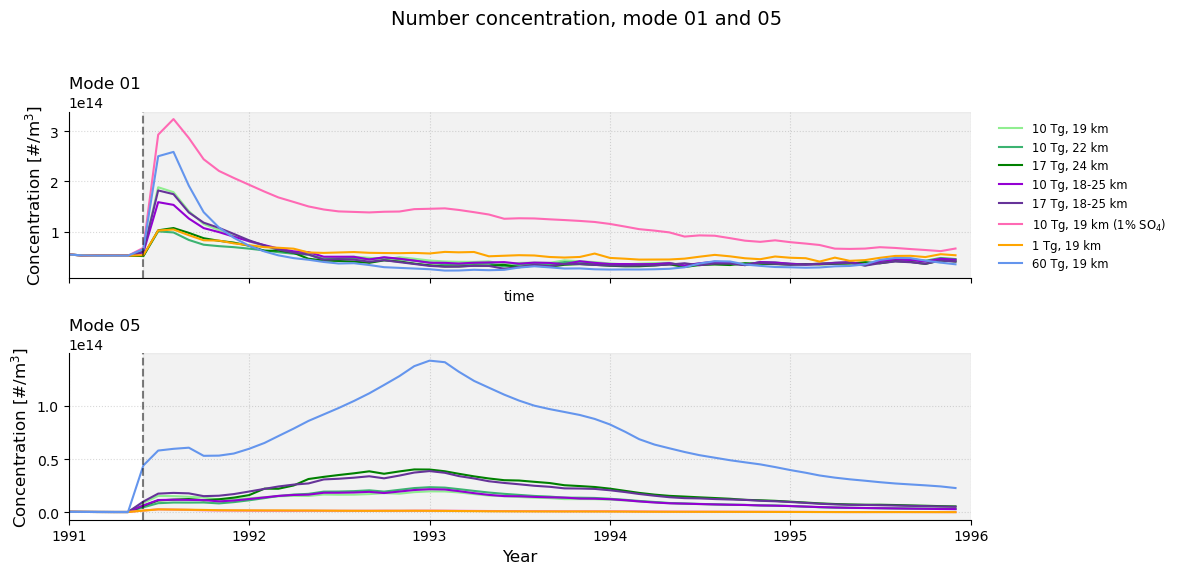

In [43]:
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
eruption_date = cftime.DatetimeNoLeap(1991, 6, 1)
end_date = cftime.DatetimeNoLeap(1996, 1, 1)
for i, mode in enumerate(so4_modes):
    ax = axs[i]
    for d, w, p, label, color in zip(datasets, weights, levels, labels, colors):
        var_name = f"NCONC{mode}"
        
        lev_vals = d.lev.values
        lev_diff = np.abs(np.gradient(lev_vals))
        wl = xr.DataArray(lev_diff, coords={'lev': d.lev}, dims=['lev'])
        
        nconc = d[var_name].where(d["lev"] <= p)
    
        nconc_h = nconc.weighted(w).mean(dim=["lat", "lon"])
        nconc_final = nconc_h.weighted(wl).mean(dim="lev") * m_to_mym
        
        nconc_final.plot(ax=ax, color=color, label=label, add_legend=False)
    
    ax.set_ylabel(f"Concentration [#/m$^3$]", fontsize=12)
    ax.set_title(f"Mode {mode}", loc='left')
    ax.grid(True, color="gray", alpha=0.3, linestyle=":")
    
    ax.axvline(eruption_date, color='black', ls="--", alpha=0.5)
    ax.axvspan(eruption_date, end_date, color='gray', alpha=0.1, zorder=0)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    if i == 0:
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize='small', frameon=False)

years = np.arange(1991, 1997)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
ax.set_xticks(year_ticks)
ax.set_xticklabels([str(y) for y in years])
ax.set_xlabel("Year", fontsize=12)

ax.set_xlim(cftime.DatetimeNoLeap(1991, 1, 1), cftime.DatetimeNoLeap(1996, 1, 1))
plt.suptitle("Number concentration, mode 01 and 05", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2559790/3521692325.py:14: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("R$_{eff}$ [$\mu$m]", fontsize=12)


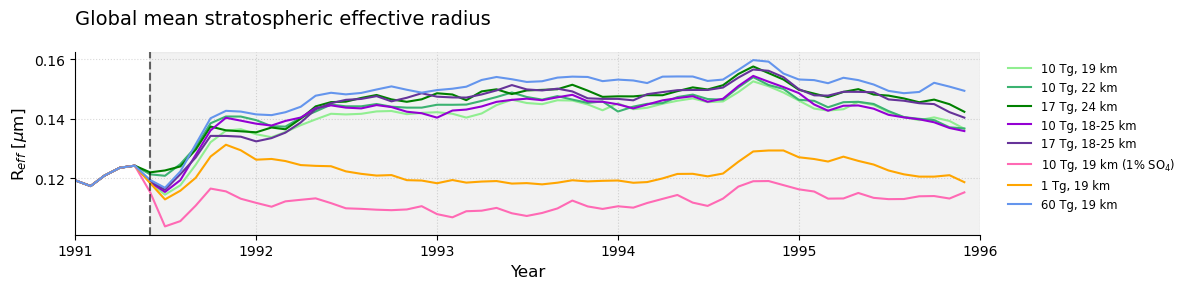

In [44]:
experiments = [SReff_19_c, SReff_22, SReff_24, SReff_1825, SReff_1825_17tg, SReff_1pr, SReff_1tg, SReff_60tg]

eruption_date = cftime.DatetimeNoLeap(1991, 6, 1)
end_date = cftime.DatetimeNoLeap(1996, 1, 1)

fig, ax = plt.subplots(1, 1, figsize=(12, 3))

for e, label, color in zip(experiments, labels, colors):
    ax.plot(e.time, e, color=color, label=label, linewidth=1.5)

ax.axvline(eruption_date, color='black', ls="--", alpha=0.6)
ax.axvspan(eruption_date, end_date, color='gray', alpha=0.1, zorder=0)

ax.set_ylabel("R$_{eff}$ [$\mu$m]", fontsize=12)
ax.set_xlabel("Year", fontsize=12)
ax.grid(True, color="gray", alpha=0.3, linestyle=":")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

years = np.arange(1991, 1997)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
ax.set_xticks(year_ticks)
ax.set_xticklabels([str(y) for y in years])
ax.set_xlim(cftime.DatetimeNoLeap(1991, 1, 1), cftime.DatetimeNoLeap(1996, 1, 1))

ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize='small', frameon=False)
plt.title("Global mean stratospheric effective radius", fontsize=14, loc='left', pad=20)

plt.tight_layout()
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2559790/4289087596.py:5: SyntaxWarning: invalid escape sequence '\m'
  ("Number Median Radius: Mode 01", "NMR", "01", "[$\mu$m]"),
/tmp/ipykernel_2559790/4289087596.py:6: SyntaxWarning: invalid escape sequence '\m'
  ("Number Median Radius: Mode 05", "NMR", "05", "[$\mu$m]"),
/tmp/ipykernel_2559790/4289087596.py:9: SyntaxWarning: invalid escape sequence '\m'
  ("Stratospheric Effective Radius", "SREFF", "", "[$\mu$m]")


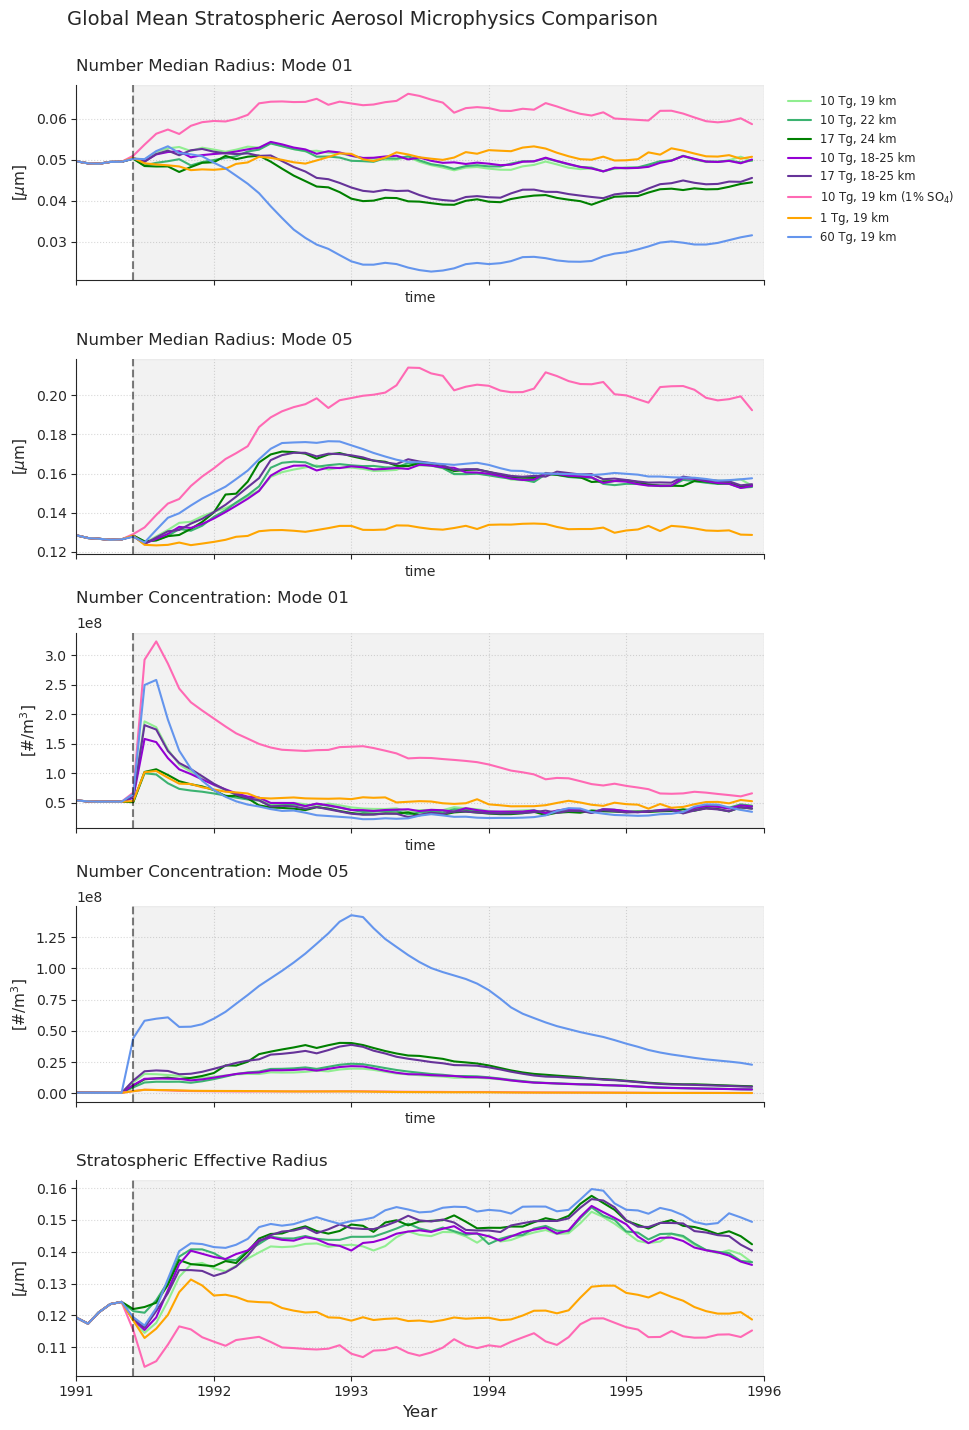

In [45]:
sns.set_style("ticks")
fig, axs = plt.subplots(5, 1, figsize=(12, 15), sharex=True)

panel_info = [
    ("Number Median Radius: Mode 01", "NMR", "01", "[$\mu$m]"),
    ("Number Median Radius: Mode 05", "NMR", "05", "[$\mu$m]"),
    ("Number Concentration: Mode 01", "NCONC", "01", "[#/m$^3$]"),
    ("Number Concentration: Mode 05", "NCONC", "05", "[#/m$^3$]"),
    ("Stratospheric Effective Radius", "SREFF", "", "[$\mu$m]")
]

for i, (title, var_prefix, mode, unit) in enumerate(panel_info):
    ax = axs[i]
    
    if var_prefix != "SREFF":
        for j, (d, w, p, label, color) in enumerate(zip(datasets, weights, levels, labels, colors)):
            lev_vals = d.lev.values
            lev_diff = np.abs(np.gradient(lev_vals))
            wl = xr.DataArray(lev_diff, coords={'lev': d.lev}, dims=['lev'])
            
            var_name = f"{var_prefix}{mode}"
            raw_data = d[var_name].where(d["lev"] <= p)
            
            h_mean = raw_data.weighted(w).mean(dim=["lat", "lon"])
            
            data = h_mean.weighted(wl).mean(dim="lev")
            
            if var_prefix == "NMR":
                data = data * m_to_mym
                
            data.plot(ax=ax, color=color, label=label, add_legend=False)
            
    else:
        for j, (e, label, color) in enumerate(zip(experiments, labels, colors)):
            e.plot(ax=ax, color=color, label=label, add_legend=False)

    ax.set_title(title, loc='left', fontsize=12, pad=10)
    ax.set_ylabel(unit, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, color="gray", alpha=0.3, linestyle=":")
      
    ax.axvline(eruption_date, color='black', ls="--", alpha=0.5)
    ax.axvspan(eruption_date, end_date, color='gray', alpha=0.1, zorder=0)
    
    if i == 0:
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize='small', frameon=False)

years = np.arange(1991, 1997)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
ax.set_xticks(year_ticks)
ax.set_xticklabels([str(y) for y in years])
ax.set_xlabel("Year", fontsize=12)

ax.set_xlim(cftime.DatetimeNoLeap(1991, 1, 1), cftime.DatetimeNoLeap(1996, 1, 1))

plt.suptitle("Global Mean Stratospheric Aerosol Microphysics Comparison", fontsize=14, x=0.06, 
             horizontalalignment='left')

plt.tight_layout(rect=[0, 0.03, 0.82, 0.98]) 
plt.subplots_adjust(hspace=0.4)

plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2559790/3420243047.py:46: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel(f"Radius [$\mu$m]", fontsize=12)


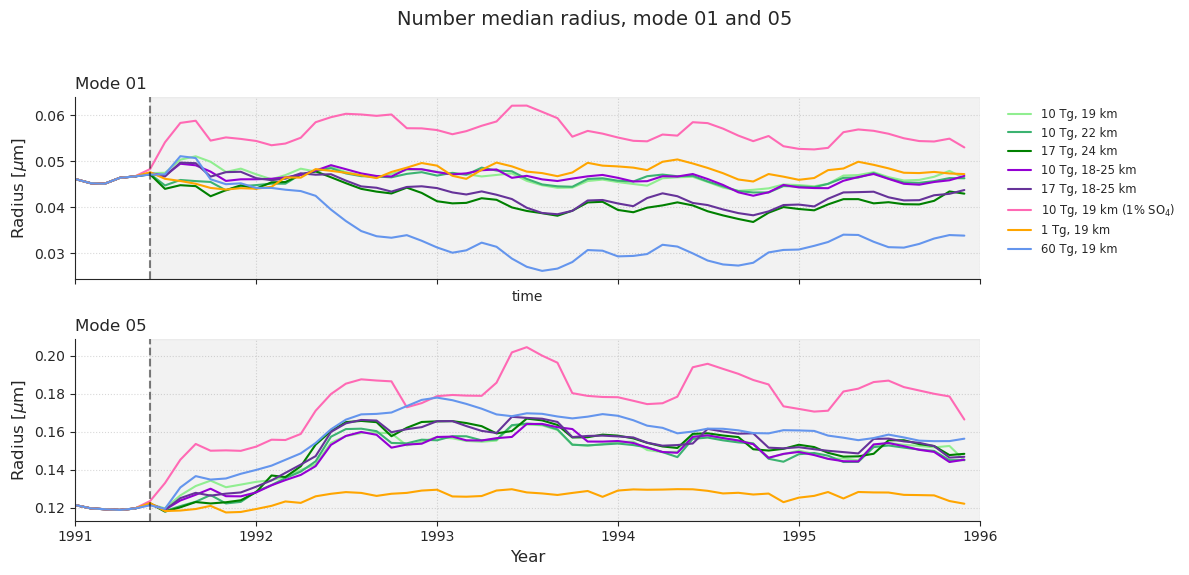

In [71]:
so4_modes = ["01", "05"]
datasets = [ds_19_c, ds_22, ds_24, 
            ds_1825, ds_1825_17tg, ds_1pr, 
            ds_1tg, ds_60tg]

levels = [p_lev_19_c, p_lev_22, p_lev_24, 
          p_lev_1825, p_lev_1825_17tg, p_lev_1pr, 
          p_lev_1tg, p_lev_60tg]

weights = [weighted_lat_19_c, weighted_lat_22, weighted_lat_24, 
           weighted_lat_1825, weighted_lat_1825_17tg, weighted_lat_1pr, 
           weighted_lat_1tg, weighted_lat_60tg]

labels = ["10 Tg, 19 km", 
          "10 Tg, 22 km", 
          "17 Tg, 24 km", 
          "10 Tg, 18-25 km", 
          "17 Tg, 18-25 km", 
          "10 Tg, 19 km (1% SO$_4$)", 
          "1 Tg, 19 km", 
          "60 Tg, 19 km"]

colors =["lightgreen", "mediumseagreen", "green", "darkviolet", "rebeccapurple", "hotpink", "orange", "cornflowerblue"]

eruption_date = cftime.DatetimeNoLeap(1991, 6, 1)
end_date = cftime.DatetimeNoLeap(1996, 1, 1)

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for i, mode in enumerate(so4_modes):
    ax = axs[i]
    for d, w, p, label, color in zip(datasets, weights, levels, labels, colors):
        var_name = f"NMR{mode}"
        
        lev_vals = d.lev.values
        lev_diff = np.abs(np.gradient(lev_vals))
        wl = xr.DataArray(lev_diff, coords={'lev': d.lev}, dims=['lev'])
        
        nmr = d[var_name].where(d["lev"] <= p)
        w_sliced = w.sel(lat=slice(-20, 20))
        nmr_h = nmr.sel(lat=slice(-20,20)).weighted(w_sliced).mean(dim=["lat", "lon"])
        nmr_final = nmr_h.weighted(wl).mean(dim="lev") * m_to_mym
        
        nmr_final.plot(ax=ax, color=color, label=label, add_legend=False)
    
    ax.set_ylabel(f"Radius [$\mu$m]", fontsize=12)
    ax.set_title(f"Mode {mode}", loc='left')
    ax.grid(True, color="gray", alpha=0.3, linestyle=":")
    
    ax.axvline(eruption_date, color='black', ls="--", alpha=0.5)
    ax.axvspan(eruption_date, end_date, color='gray', alpha=0.1, zorder=0)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    if i == 0:
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize='small', frameon=False)

years = np.arange(1991, 1997)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
ax.set_xticks(year_ticks)
ax.set_xticklabels([str(y) for y in years])
ax.set_xlabel("Year", fontsize=12)

ax.set_xlim(cftime.DatetimeNoLeap(1991, 1, 1), cftime.DatetimeNoLeap(1996, 1, 1))
plt.suptitle("Number median radius, mode 01 and 05", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

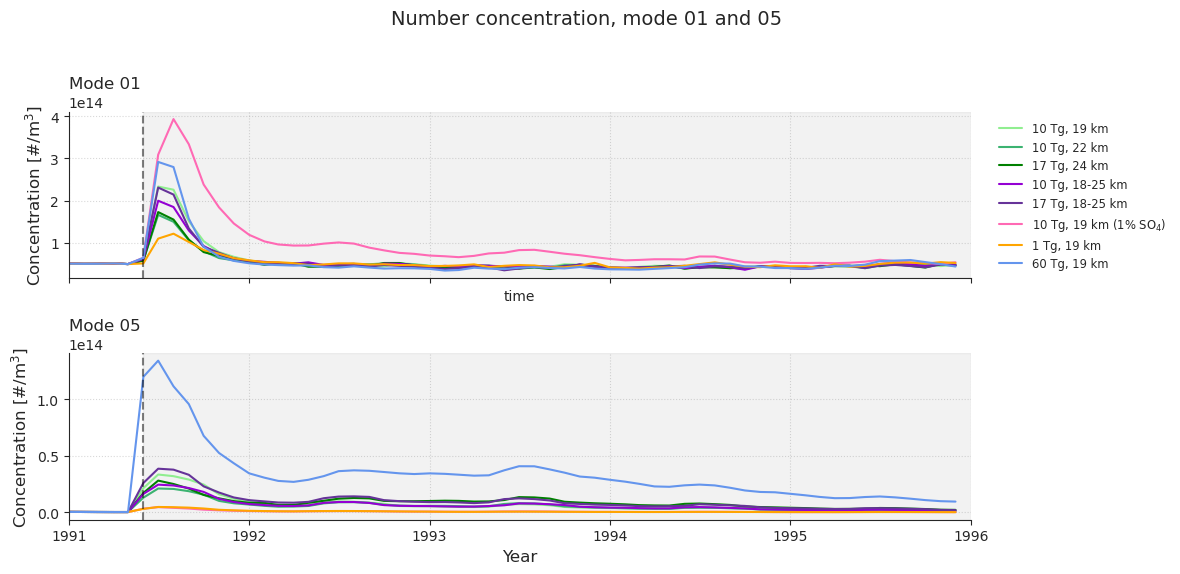

In [72]:
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
eruption_date = cftime.DatetimeNoLeap(1991, 6, 1)
end_date = cftime.DatetimeNoLeap(1996, 1, 1)
for i, mode in enumerate(so4_modes):
    ax = axs[i]
    for d, w, p, label, color in zip(datasets, weights, levels, labels, colors):
        var_name = f"NCONC{mode}"
        
        lev_vals = d.lev.values
        lev_diff = np.abs(np.gradient(lev_vals))
        wl = xr.DataArray(lev_diff, coords={'lev': d.lev}, dims=['lev'])
        
        nconc = d[var_name].where(d["lev"] <= p)
        w_sliced = w.sel(lat=slice(-20, 20))
        nconc_h = nconc.sel(lat=slice(-20,20)).weighted(w_sliced).mean(dim=["lat", "lon"])
        nconc_final = nconc_h.weighted(wl).mean(dim="lev") * m_to_mym
        
        nconc_final.plot(ax=ax, color=color, label=label, add_legend=False)
    
    ax.set_ylabel(f"Concentration [#/m$^3$]", fontsize=12)
    ax.set_title(f"Mode {mode}", loc='left')
    ax.grid(True, color="gray", alpha=0.3, linestyle=":")
    
    ax.axvline(eruption_date, color='black', ls="--", alpha=0.5)
    ax.axvspan(eruption_date, end_date, color='gray', alpha=0.1, zorder=0)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    if i == 0:
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize='small', frameon=False)

years = np.arange(1991, 1997)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
ax.set_xticks(year_ticks)
ax.set_xticklabels([str(y) for y in years])
ax.set_xlabel("Year", fontsize=12)

ax.set_xlim(cftime.DatetimeNoLeap(1991, 1, 1), cftime.DatetimeNoLeap(1996, 1, 1))
plt.suptitle("Number concentration, mode 01 and 05", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2559790/2868610767.py:7: SyntaxWarning: invalid escape sequence '\m'
  ("Number Median Radius: Mode 01", "NMR", "01", "[$\mu$m]"),
/tmp/ipykernel_2559790/2868610767.py:8: SyntaxWarning: invalid escape sequence '\m'
  ("Number Median Radius: Mode 05", "NMR", "05", "[$\mu$m]"),
/tmp/ipykernel_2559790/2868610767.py:11: SyntaxWarning: invalid escape sequence '\m'
  ("Stratospheric Effective Radius", "SREFF", "", "[$\mu$m]")


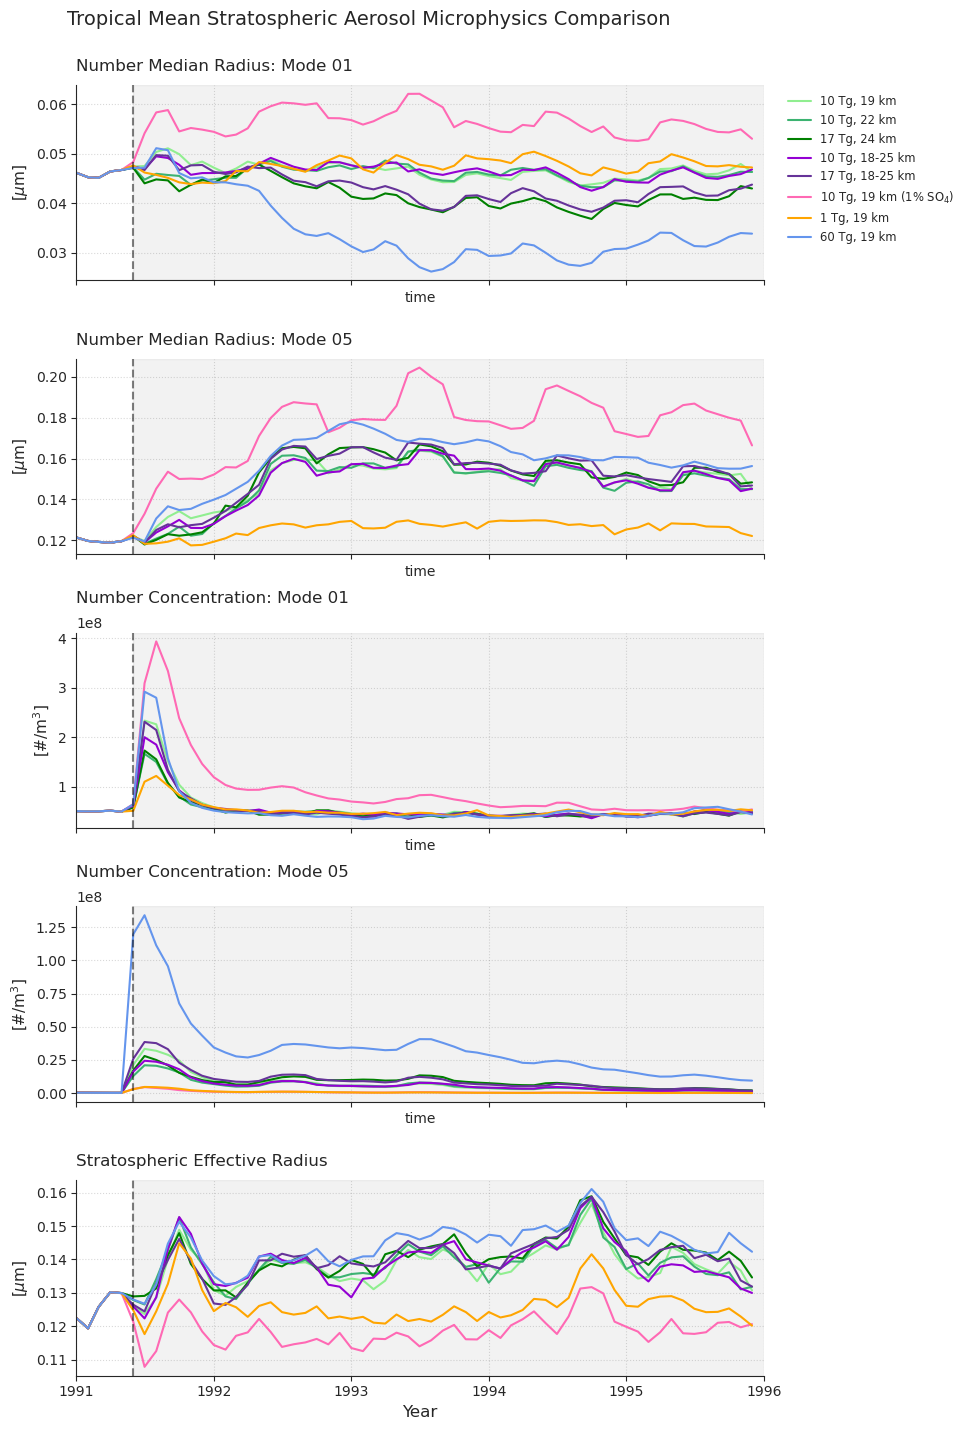

In [74]:
experiments = [SReff_19_c_trop, SReff_22_trop, SReff_24_trop, SReff_1825_trop, SReff_1825_17tg_trop, SReff_1pr_trop, SReff_1tg_trop, SReff_60tg_trop]

sns.set_style("ticks")
fig, axs = plt.subplots(5, 1, figsize=(12, 15), sharex=True)

panel_info = [
    ("Number Median Radius: Mode 01", "NMR", "01", "[$\mu$m]"),
    ("Number Median Radius: Mode 05", "NMR", "05", "[$\mu$m]"),
    ("Number Concentration: Mode 01", "NCONC", "01", "[#/m$^3$]"),
    ("Number Concentration: Mode 05", "NCONC", "05", "[#/m$^3$]"),
    ("Stratospheric Effective Radius", "SREFF", "", "[$\mu$m]")
]

for i, (title, var_prefix, mode, unit) in enumerate(panel_info):
    ax = axs[i]
    
    if var_prefix != "SREFF":
        for j, (d, w, p, label, color) in enumerate(zip(datasets, weights, levels, labels, colors)):
            lev_vals = d.lev.values
            lev_diff = np.abs(np.gradient(lev_vals))
            wl = xr.DataArray(lev_diff, coords={'lev': d.lev}, dims=['lev'])
            
            var_name = f"{var_prefix}{mode}"
            raw_data = d[var_name].where(d["lev"] <= p)
            w_sliced = w.sel(lat=slice(-20, 20))
            h_mean = raw_data.sel(lat=slice(-20,20)).weighted(w_sliced).mean(dim=["lat", "lon"])
            
            data = h_mean.weighted(wl).mean(dim="lev")
            
            if var_prefix == "NMR":
                data = data * m_to_mym
                
            data.plot(ax=ax, color=color, label=label, add_legend=False)
            
    else:
        for j, (e, label, color) in enumerate(zip(experiments, labels, colors)):
            e.plot(ax=ax, color=color, label=label, add_legend=False)

    ax.set_title(title, loc='left', fontsize=12, pad=10)
    ax.set_ylabel(unit, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, color="gray", alpha=0.3, linestyle=":")
      
    ax.axvline(eruption_date, color='black', ls="--", alpha=0.5)
    ax.axvspan(eruption_date, end_date, color='gray', alpha=0.1, zorder=0)
    
    if i == 0:
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize='small', frameon=False)

years = np.arange(1991, 1997)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
ax.set_xticks(year_ticks)
ax.set_xticklabels([str(y) for y in years])
ax.set_xlabel("Year", fontsize=12)

ax.set_xlim(cftime.DatetimeNoLeap(1991, 1, 1), cftime.DatetimeNoLeap(1996, 1, 1))

plt.suptitle("Tropical Mean Stratospheric Aerosol Microphysics Comparison", fontsize=14, x=0.06, 
             horizontalalignment='left')

plt.tight_layout(rect=[0, 0.03, 0.82, 0.98]) 
plt.subplots_adjust(hspace=0.4)

plt.show()

In [46]:
path_daily = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20260120_pinatubo10Tg19_daily_branch/atm/hist"
ds_daily = xr.open_dataset(f'{path_daily}/NHIST_tropstratchem_f09_tn14_20260120_Pinatubo10Tg19_daily_branch.cam.h0.1991-06-02-00000.nc')

In [47]:
lat_daily = ds_daily["lat"]
weighted_lat_daily = np.cos(np.deg2rad(lat_daily))
tropopause_daily = ds_daily["TROP_P"].weighted(weighted_lat_daily).mean(dim=["lat", "lon"])
p_lev_daily = tropopause_daily * 0.01

lev_vals_daily = ds_daily.lev.values
lev_diff_daily = np.abs(np.gradient(lev_vals_daily))
wl_daily = xr.DataArray(lev_diff_daily, coords={'lev': ds_daily.lev}, dims=['lev'])


In [48]:
Reff_daily = ds_daily["REFF_AERO"].where(ds_daily["REFF_AERO"]["lev"] <= p_lev_daily)
Reff_daily = Reff_daily.sel(lat=slice(-20, 20))
Reff_h = Reff_daily.weighted(weighted_lat_daily).mean(dim=["lev", "lat", "lon"])
Reff_daily_final = Reff_h * cm_to_mym

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2559790/2068120744.py:19: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$m")


Text(0.5, 1.0, 'Daily R$_{eff}$ in June')

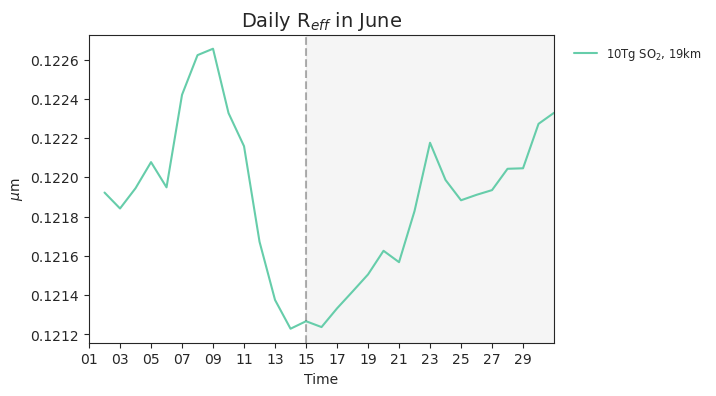

In [49]:
fig, ax = plt.subplots(figsize=(6, 4))
Reff_daily_final.plot(color="mediumaquamarine", label="10Tg SO$_2$, 19km")

eruption_date = cftime.DatetimeNoLeap(1991, 6, 15)
end_of_month = cftime.DatetimeNoLeap(1991, 7, 1)

ax.axvline(eruption_date, color='black', linestyle='--', alpha=0.3)
ax.axvspan(eruption_date, end_of_month, color='gray', alpha=0.08, zorder=0)

days = pd.date_range(start="1991-06-01", end="1991-06-30", freq="2D")
day_ticks = [cftime.DatetimeNoLeap(d.year, d.month, d.day) for d in days]

ax.set_xticks(day_ticks)
ax.set_xticklabels([d.strftime('%d') for d in days], rotation=0)
ax.set_xlim(cftime.DatetimeNoLeap(1991, 6, 1), cftime.DatetimeNoLeap(1991, 7, 1)) 

ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize='small', frameon=False)

plt.ylabel("$\mu$m")
plt.xlabel("Time")
plt.title("Daily R$_{eff}$ in June", fontsize=14)

In [50]:
SReff_daily = compute_SReff_hybrid(ds_daily,  p_lev_lower=p_lev_daily) #, lat_range=(40,43), lon_range=(105, 106.5))

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2559790/437920407.py:12: SyntaxWarning: invalid escape sequence '\m'
  axes[i].set_ylabel("[$\mu$m]")


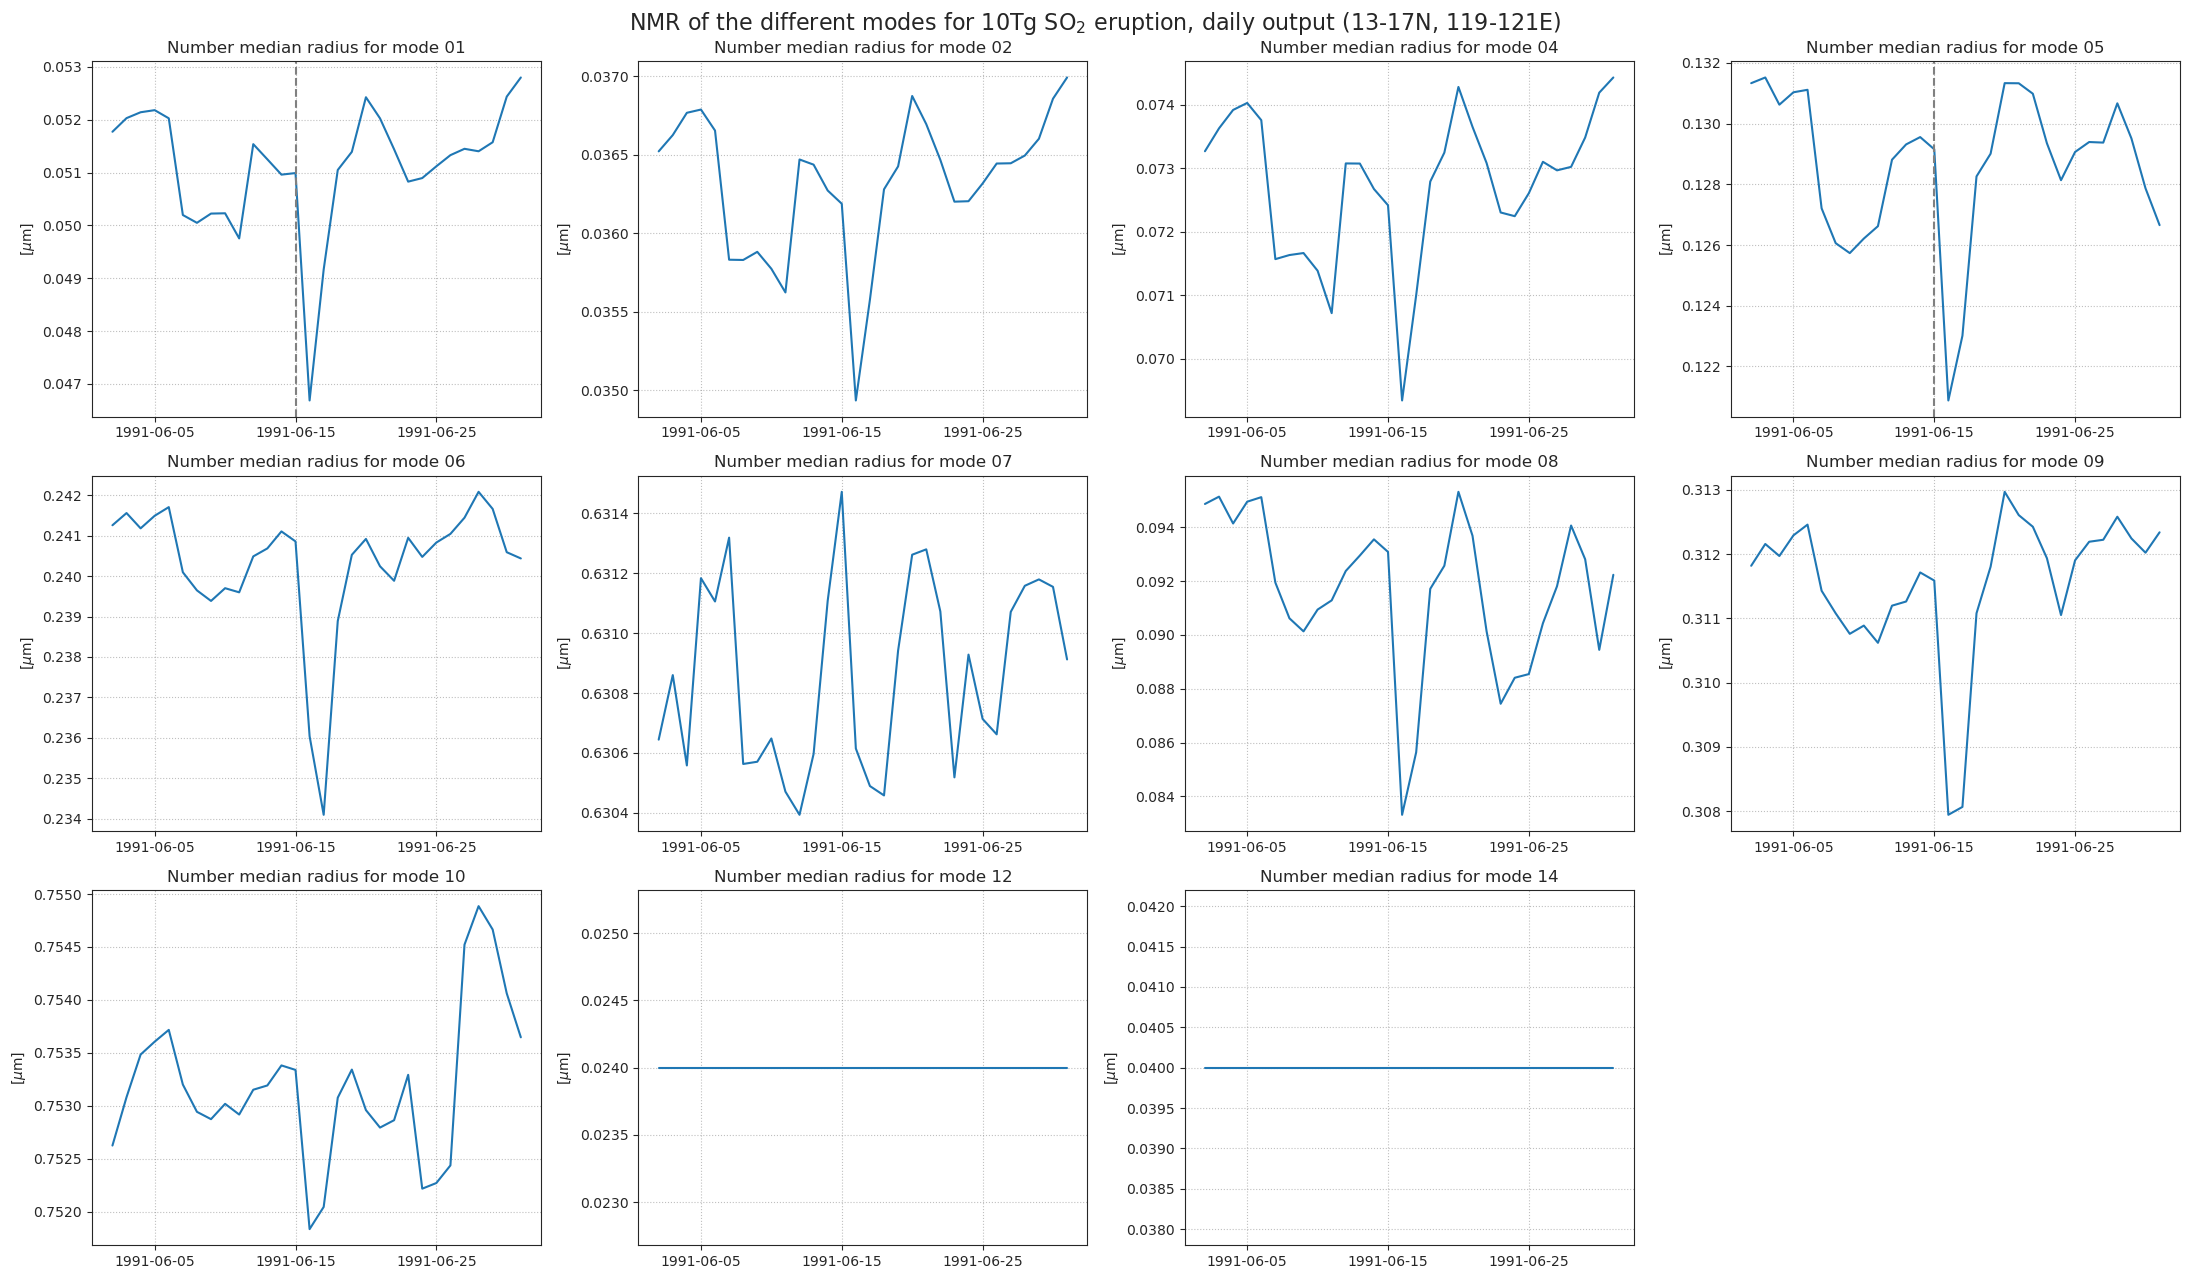

In [51]:
modes = ["01", "02", "04", "05", "06", "07", "08", "09", "10", "12", "14"]
m_to_mym = cm_to_mym*100
fig, axes = plt.subplots(3, 4, figsize=(22, 13), sharex=False, sharey=False)
axes = axes.flatten() 
for i, m in enumerate(modes):
    nmr = ds_daily[f"NMR{m}"].where(ds_daily[f"NMR{m}"]["lev"] <= p_lev_daily)
    nmr = nmr.sel(lat=slice(13,17))
    nmr = nmr.sel(lon=slice(119,121))
    nmr = nmr.weighted(weighted_lat_daily).mean(dim=["lat","lon","lev"])*m_to_mym
    axes[i].plot(nmr.time, nmr)
    axes[i].grid(color = "gray", alpha=0.5, linestyle=":")
    axes[i].set_ylabel("[$\mu$m]")
    axes[i].set_title(f"Number median radius for mode {m}")

    if m in ["01","05"]:
        t1line = cftime.DatetimeNoLeap(1991, 6, 15)
        axes[i].axvline(t1line, color="gray", linestyle="--")

for j in range(i+1, 3*4):
    fig.delaxes(axes[j])

plt.suptitle("NMR of the different modes for 10Tg SO$_2$ eruption, daily output (13-17N, 119-121E)", fontsize=16)
plt.tight_layout()
plt.show()

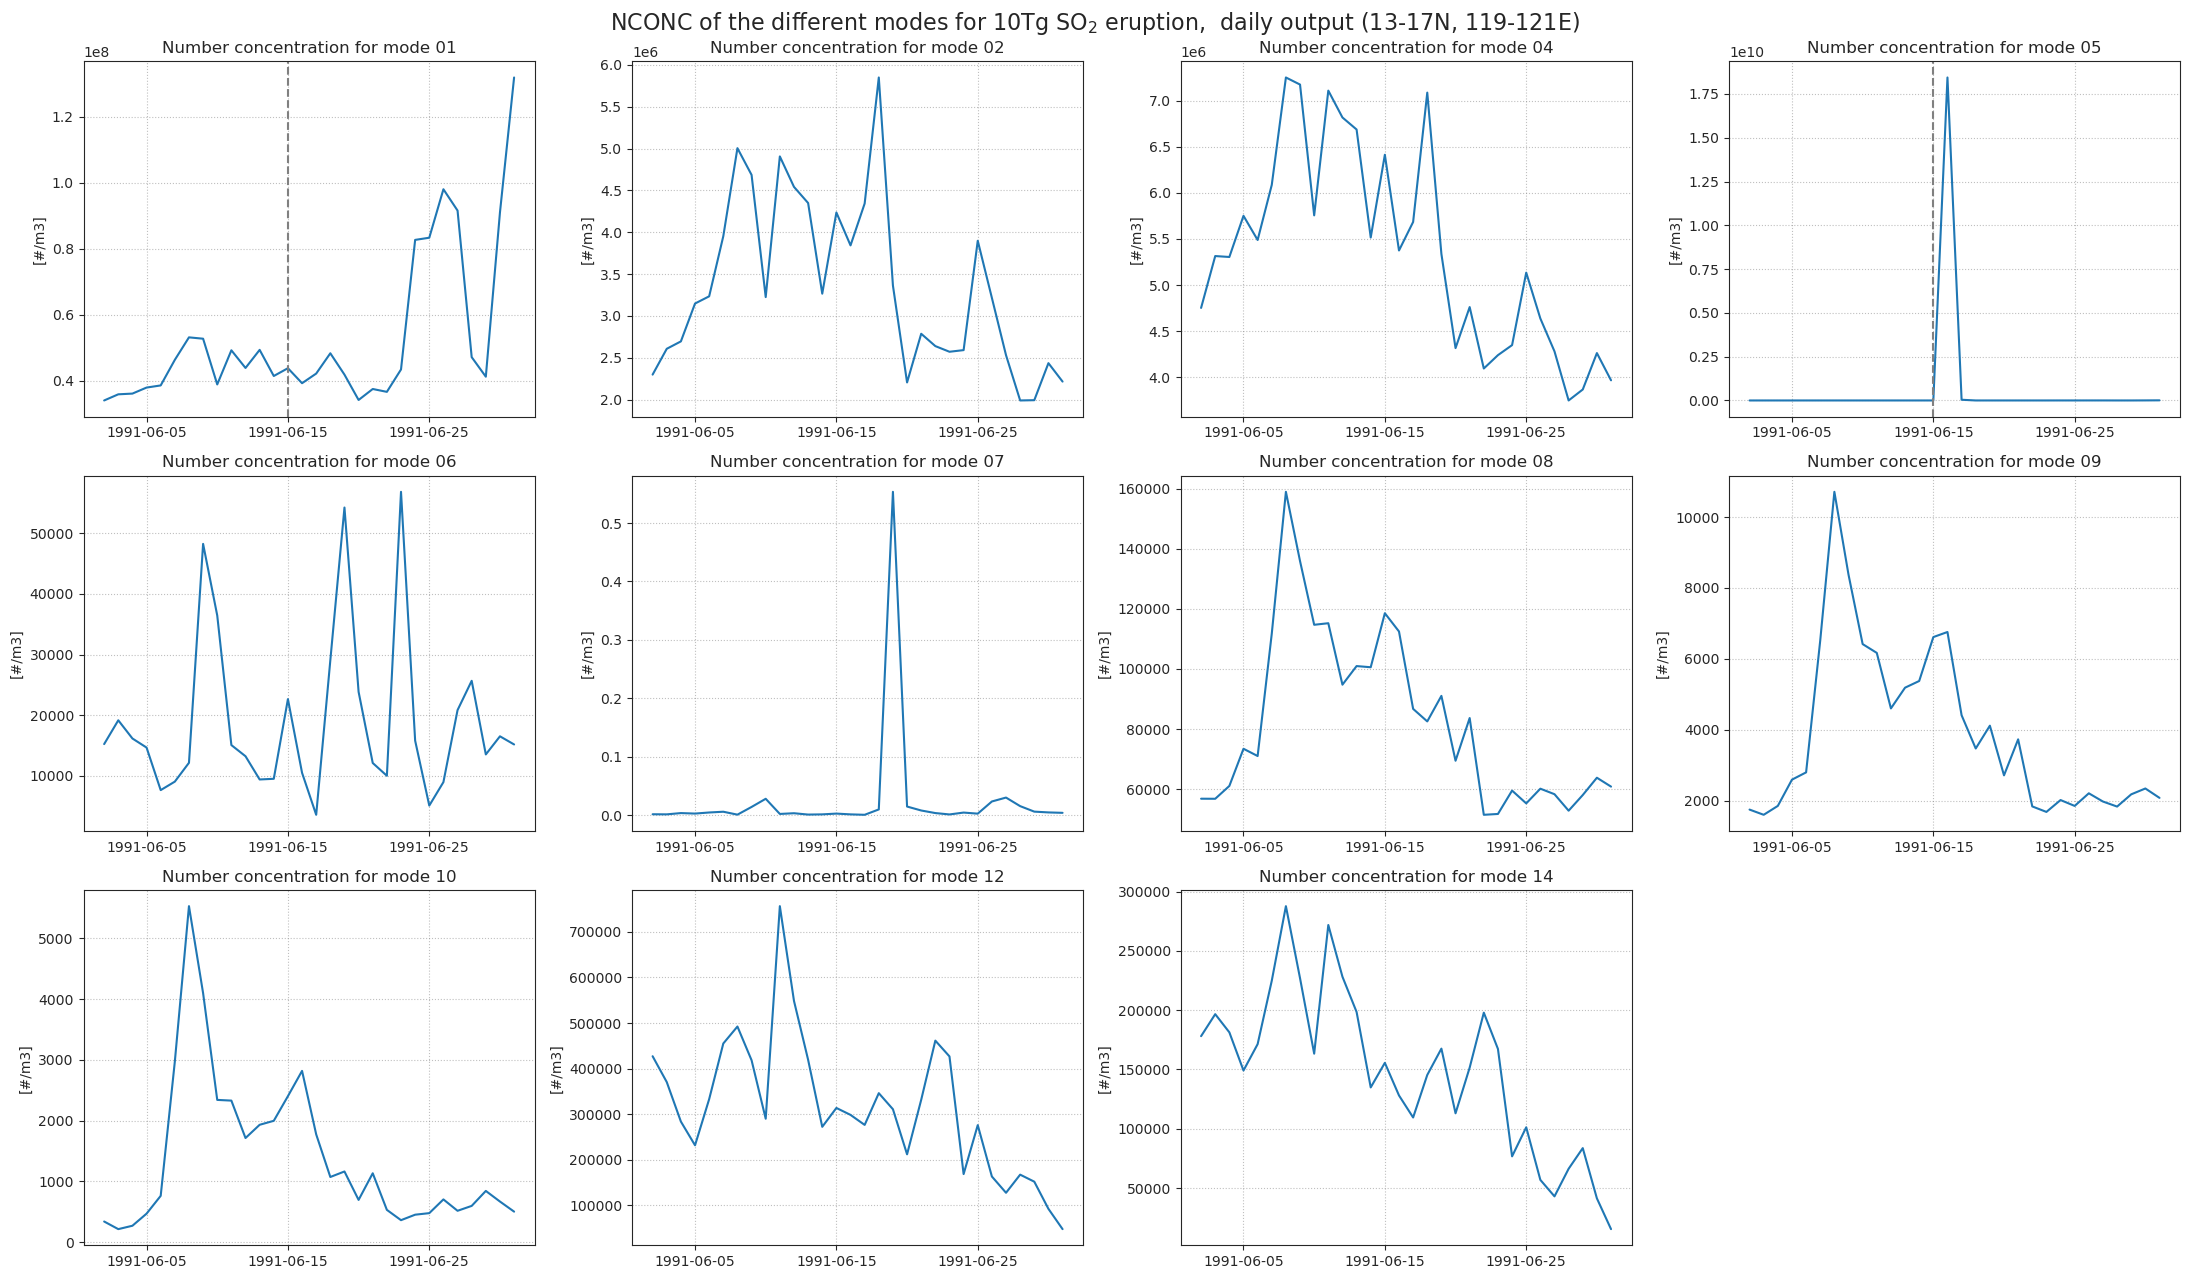

In [52]:
modes = ["01", "02", "04", "05", "06", "07", "08", "09", "10", "12", "14"]
m_to_mym = cm_to_mym*100
fig, axes = plt.subplots(3, 4, figsize=(22, 13), sharex=False, sharey=False)
axes = axes.flatten() 
for i, m in enumerate(modes):
    nconc = ds_daily[f"NCONC{m}"].where(ds_daily[f"NCONC{m}"]["lev"] <= p_lev_daily)
    nconc = nconc.sel(lat=slice(13,17))
    nconc = nconc.sel(lon=slice(119,121))
    nconc = nconc.weighted(weighted_lat_daily).mean(dim=["lat","lon","lev"])
    axes[i].plot(nconc.time, nconc)
    axes[i].grid(color = "gray", alpha=0.5, linestyle=":")
    axes[i].set_ylabel("[#/m3]")
    axes[i].set_title(f"Number concentration for mode {m}")

    if m in ["01","05"]:
        t1line = cftime.DatetimeNoLeap(1991, 6, 15)
        axes[i].axvline(t1line, color="gray", linestyle="--")

for j in range(i+1, 3*4):
    fig.delaxes(axes[j])

plt.suptitle("NCONC of the different modes for 10Tg SO$_2$ eruption,  daily output (13-17N, 119-121E)", fontsize=16)
plt.tight_layout()
plt.show()

In [53]:
ds_19_c["NCONC01"]

<xarray.DataArray 'NCONC01' (time: 60, lev: 32, lat: 192, lon: 288)> Size: 425MB
dask.array<concatenate, shape=(60, 32, 192, 288), dtype=float32, chunksize=(1, 32, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * time     (time) object 480B 1991-01-01 00:00:00 ... 1995-12-01 00:00:00
Attributes:
    mdims:         1
    units:         #/m3
    long_name:     number concentration mode 01
    cell_methods:  time: mean

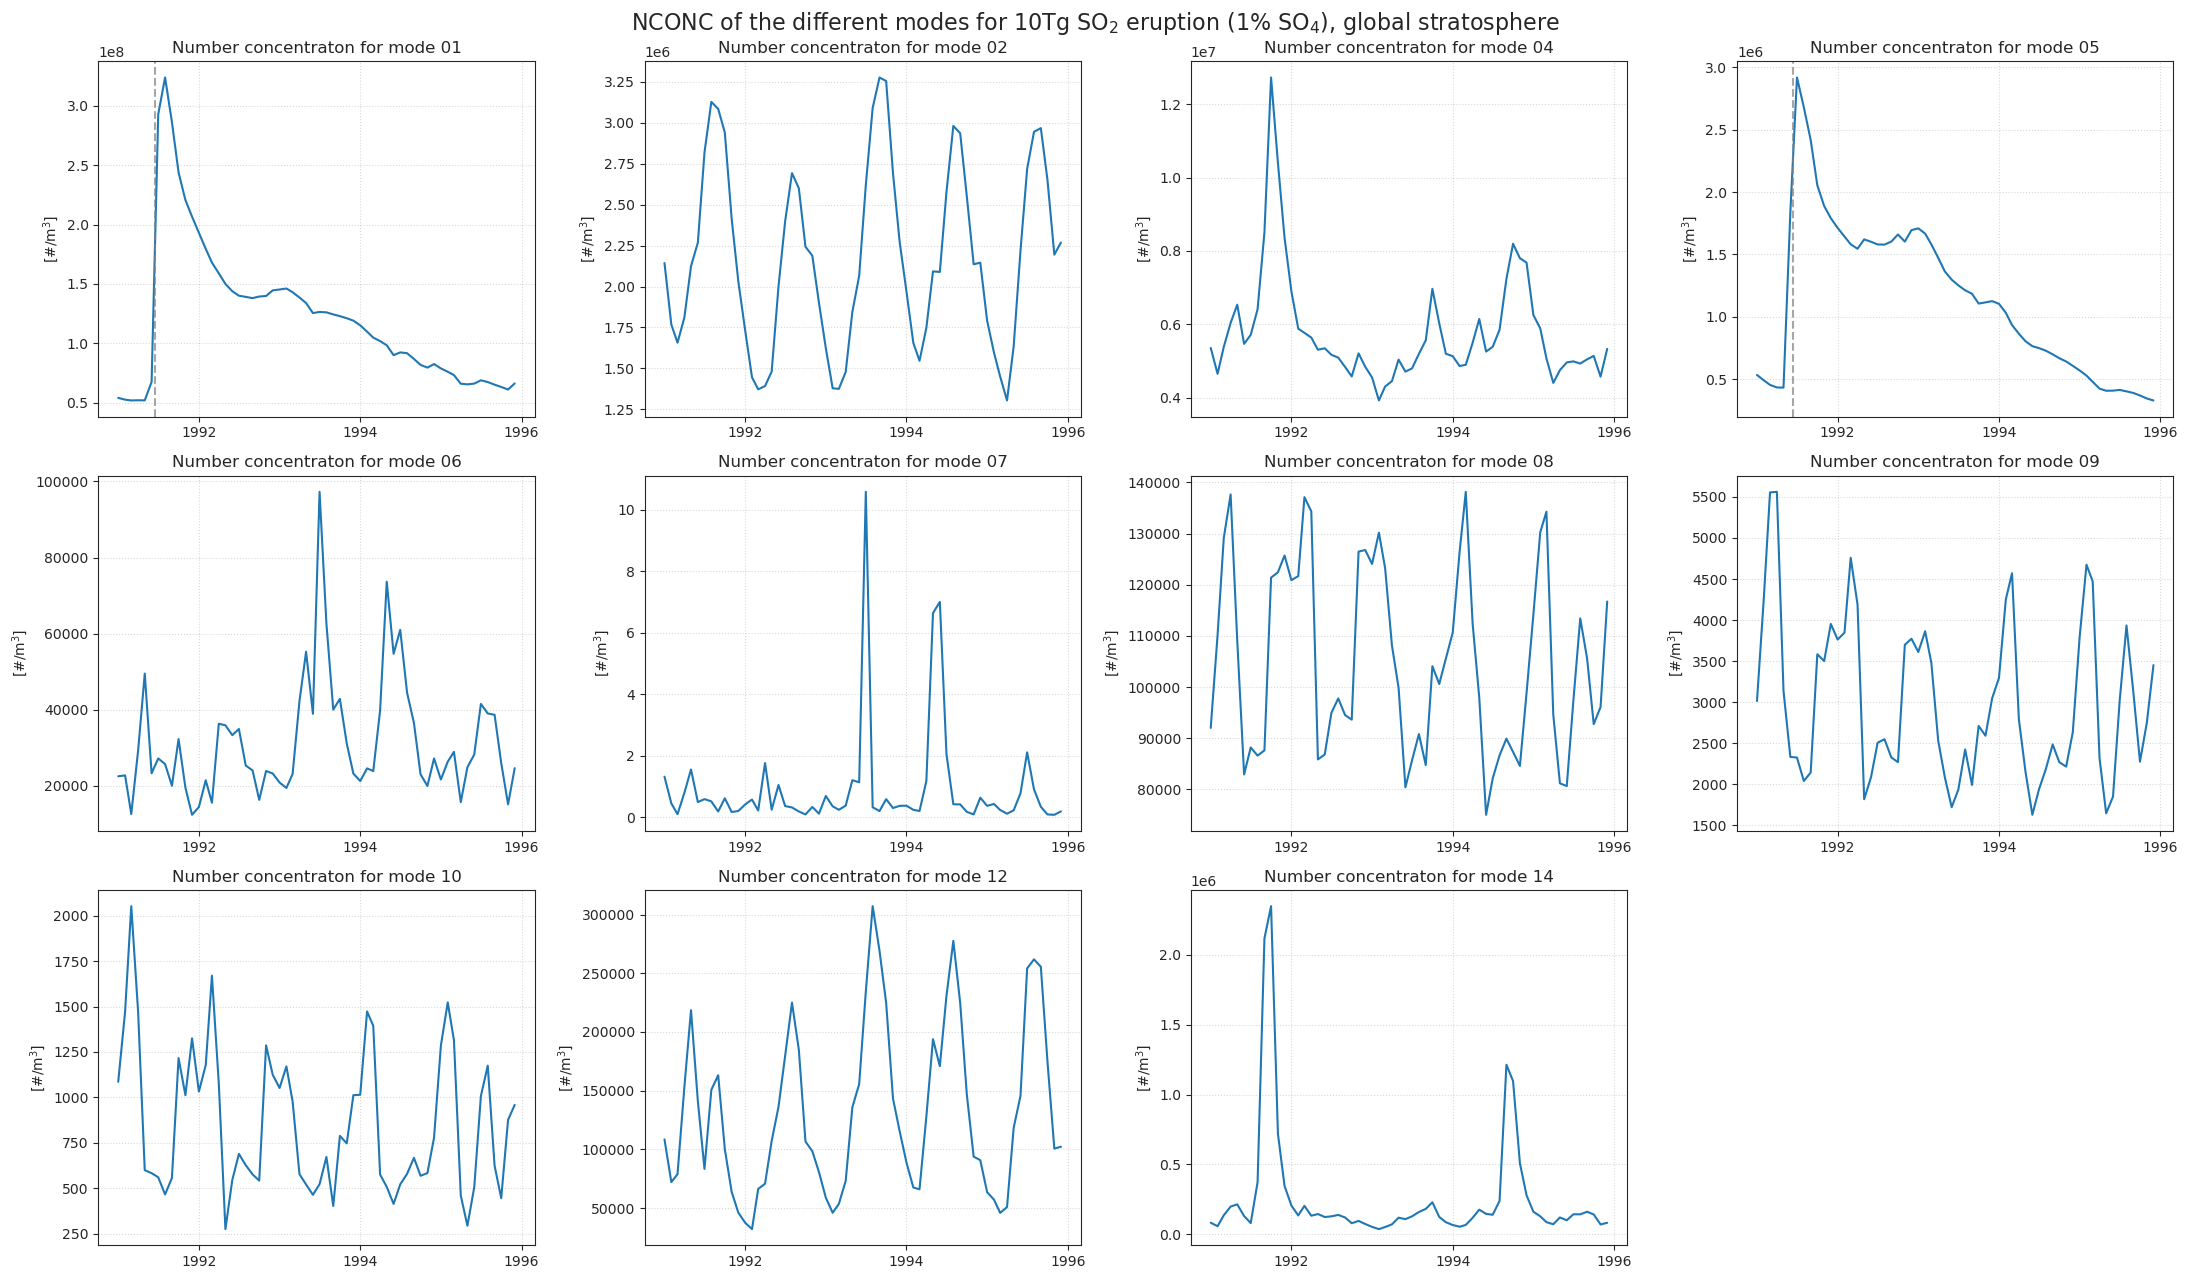

In [54]:
m_to_mym = cm_to_mym * 100
modes = ["01", "02", "04", "05", "06", "07", "08", "09", "10", "12", "14"]

fig, axes = plt.subplots(3, 4, figsize=(22, 13), sharex=False, sharey=False)
axes = axes.flatten()

lev_vals = ds_1pr.lev.values
lev_diff = np.abs(np.gradient(lev_vals))
wl_1pr = xr.DataArray(lev_diff, coords={'lev': ds_1pr.lev}, dims=['lev'])

for i, m in enumerate(modes):
    ax = axes[i]
    var_name = f"NCONC{m}"
    
    nconc = ds_1pr[var_name].where(ds_1pr["lev"] <= p_lev_1pr)
    
    nconc_h = nconc.weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
    nconc_final = nconc_h.weighted(wl_1pr).mean(dim="lev")
    
    ax.plot(nconc_final.time, nconc_final, linewidth=1.5)
    
    ax.set_ylabel("[#/m$^3$]")
    ax.set_title(f"Number concentraton for mode {m}")
    ax.grid(color="gray", alpha=0.3, linestyle=":")
    
    if m in ["01", "05"]:
        t1line = cftime.DatetimeNoLeap(1991, 6, 15)
        ax.axvline(t1line, color="gray", linestyle="--", alpha=0.7, label="Eruption")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.suptitle("NCONC of the different modes for 10Tg SO$_2$ eruption (1% SO$_4$), global stratosphere", fontsize=16)
plt.tight_layout()
plt.show()

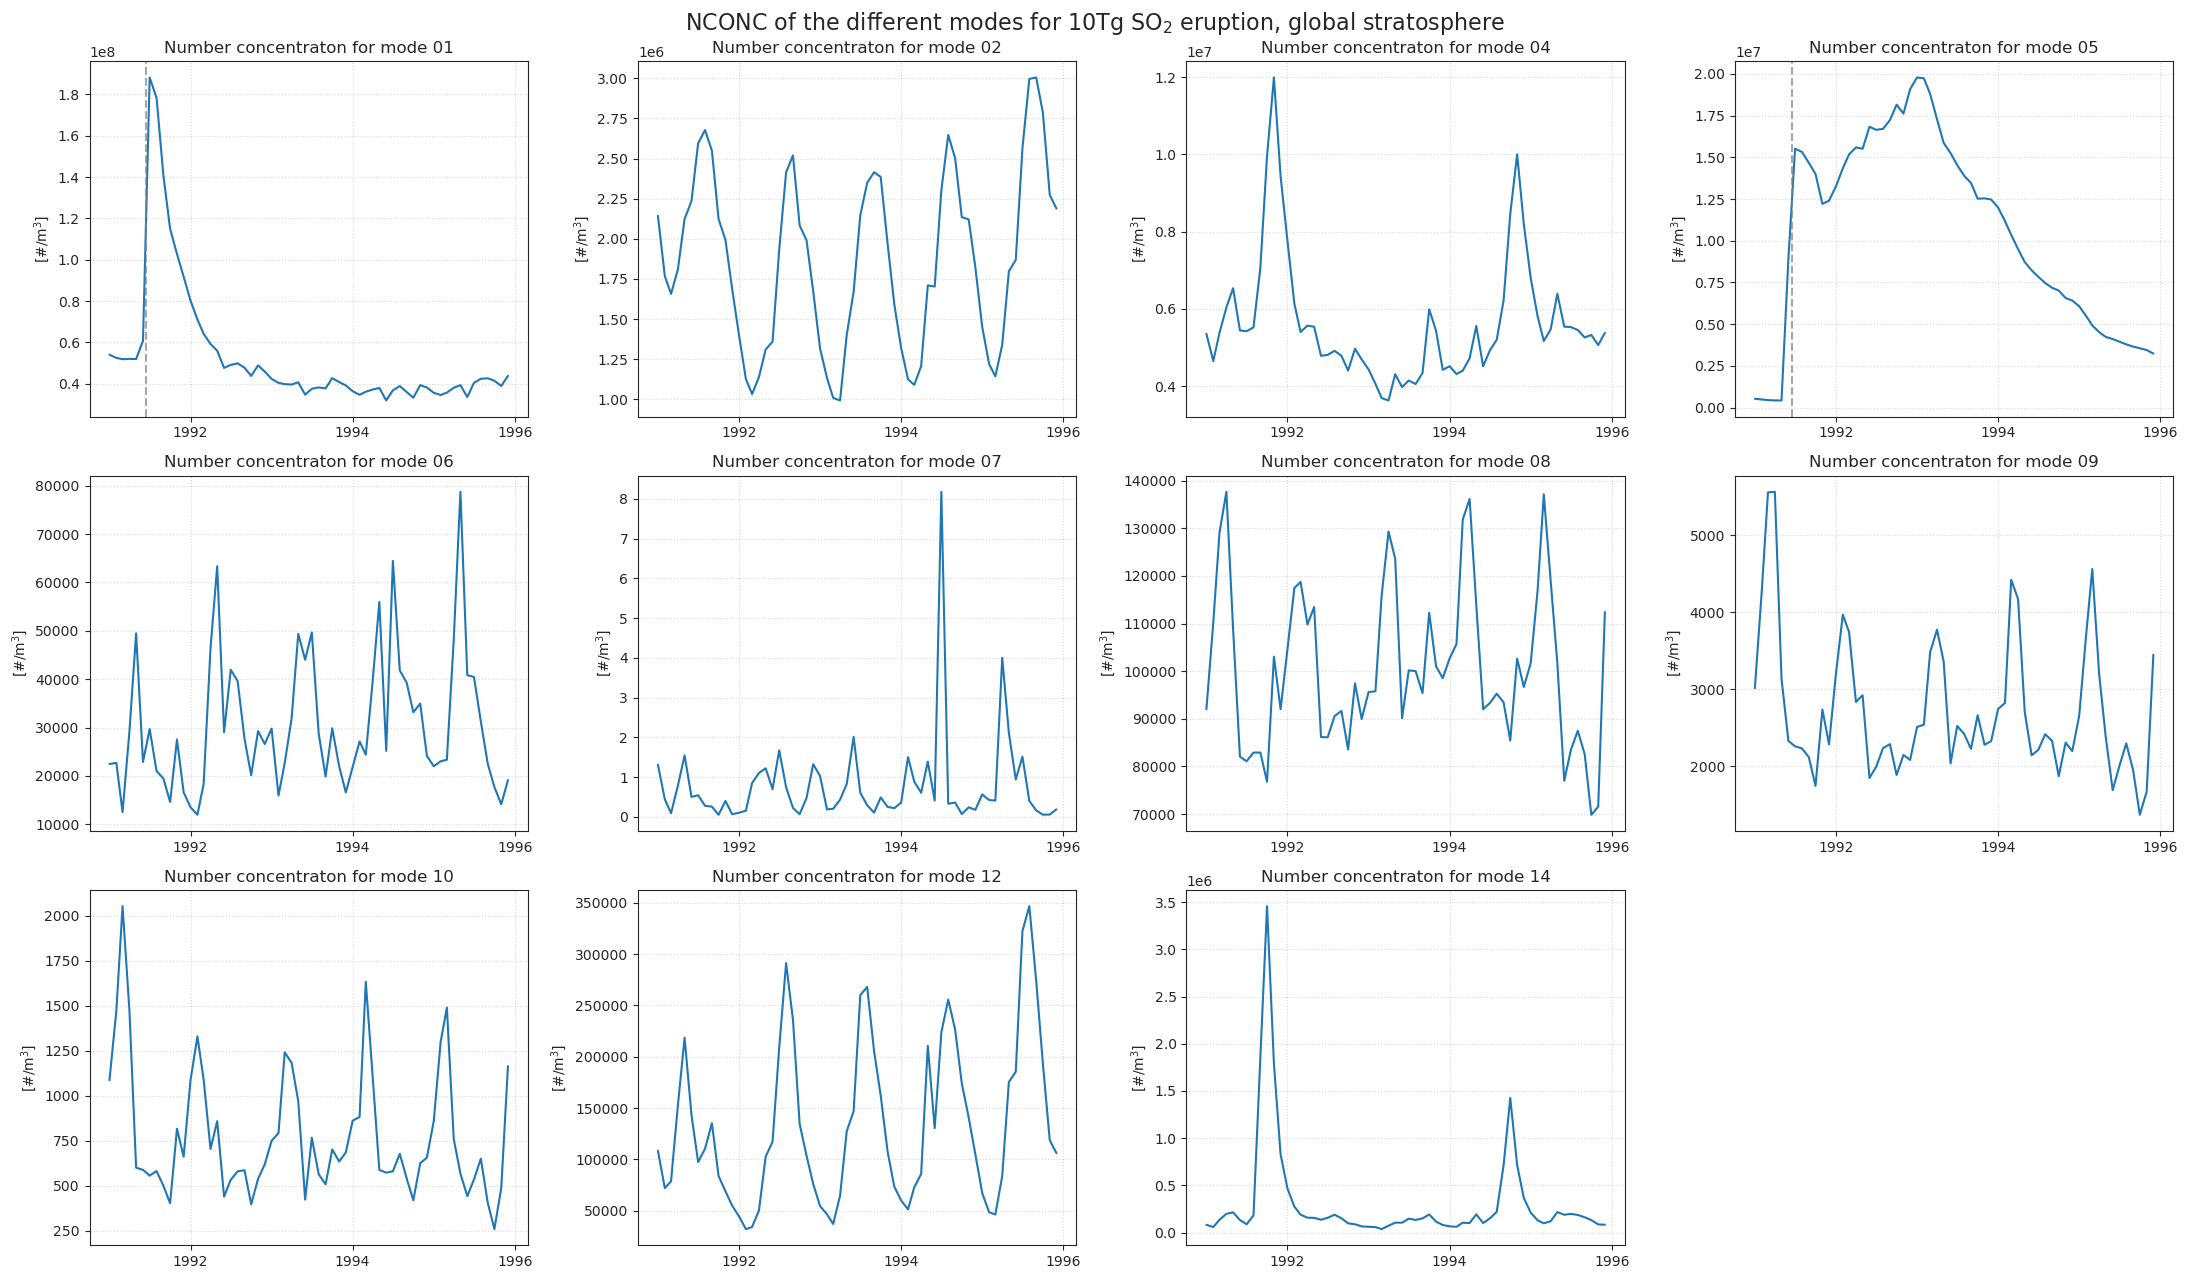

In [55]:
modes = ["01", "02", "04", "05", "06", "07", "08", "09", "10", "12", "14"]
m_to_mym = cm_to_mym*100
fig, axes = plt.subplots(3, 4, figsize=(22, 13), sharex=False, sharey=False)
axes = axes.flatten()

lev_vals = ds_19_c.lev.values
lev_diff = np.abs(np.gradient(lev_vals))
wl_19_c = xr.DataArray(lev_diff, coords={'lev': ds_19_c.lev}, dims=['lev'])

for i, m in enumerate(modes):
    ax = axes[i]
    var_name = f"NCONC{m}"
    
    nconc = ds_19_c[var_name].where(ds_19_c["lev"] <= p_lev_19_c)
    
    nconc_h = nconc.weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
    nconc_final = nconc_h.weighted(wl_19_c).mean(dim="lev")
    
    ax.plot(nconc_final.time, nconc_final, linewidth=1.5)
    
    ax.set_ylabel("[#/m$^3$]")
    ax.set_title(f"Number concentraton for mode {m}")
    ax.grid(color="gray", alpha=0.3, linestyle=":")
    
    if m in ["01", "05"]:
        t1line = cftime.DatetimeNoLeap(1991, 6, 15)
        ax.axvline(t1line, color="gray", linestyle="--", alpha=0.7, label="Eruption")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("NCONC of the different modes for 10Tg SO$_2$ eruption, global stratosphere", fontsize=16)
plt.tight_layout()
plt.show()

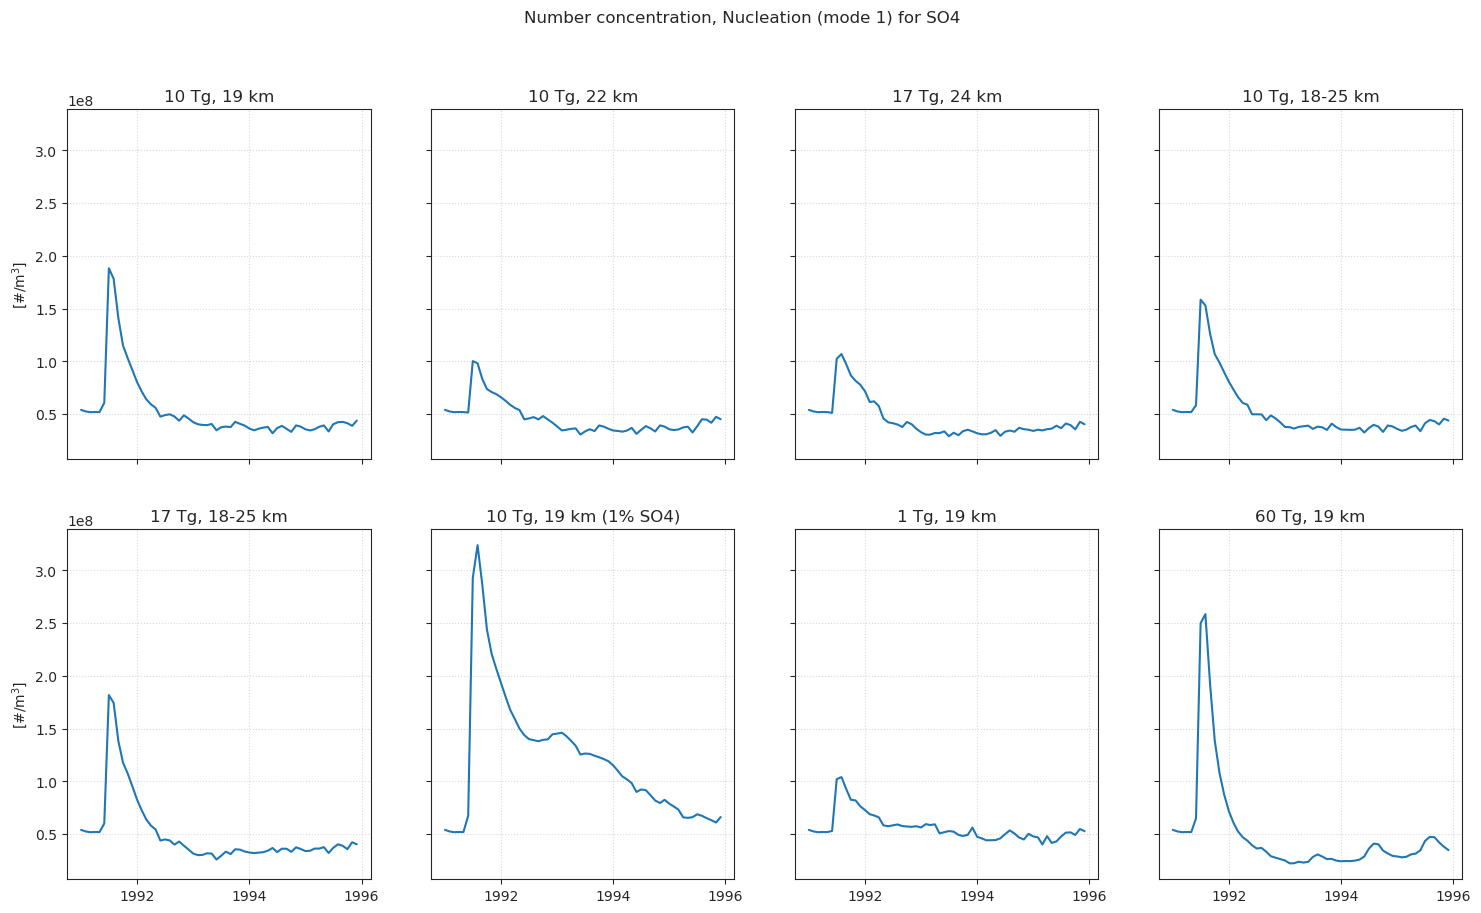

In [56]:
ds = [ds_19_c, ds_22, ds_24, 
      ds_1825, ds_1825_17tg, ds_1pr, 
      ds_1tg, ds_60tg]
levels = [p_lev_19_c, p_lev_22, p_lev_24, 
          p_lev_1825, p_lev_1825_17tg, p_lev_1pr,
          p_lev_1tg, p_lev_60tg]
weights = [weighted_lat_19_c, weighted_lat_22, weighted_lat_24,
           weighted_lat_1825, weighted_lat_1825_17tg, weighted_lat_1pr,
           weighted_lat_1tg, weighted_lat_60tg]

titles = ["10 Tg, 19 km", 
          "10 Tg, 22 km", 
          "17 Tg, 24 km", 
          "10 Tg, 18-25 km", 
          "17 Tg, 18-25 km", 
          "10 Tg, 19 km (1% SO4)", 
          "1 Tg, 19 km", 
          "60 Tg, 19 km"]

fig, axs = plt.subplots(2, 4, figsize=(18, 10), sharex=True, sharey=True)

for ax, current_ds, w, p, title in zip(axs.flat, ds, weights, levels, titles):
    lev_vals = current_ds.lev.values
    lev_diff = np.abs(np.gradient(lev_vals))
    wl = xr.DataArray(lev_diff, coords={'lev': current_ds.lev}, dims=['lev'])
    
    nconc_raw = current_ds["NCONC01"].where(current_ds["lev"] <= p)
    
    nconc_h = nconc_raw.weighted(w).mean(dim=["lat", "lon"])
    nconc_final = nconc_h.weighted(wl).mean(dim="lev")
    nconc_final.plot(ax=ax)
    
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("[#/m$^3$]" if ax in axs[:, 0] else "")
    ax.set_xlabel("") 
    ax.grid(color="gray", alpha=0.3, linestyle=":")

plt.suptitle("Number concentration, Nucleation (mode 1) for SO4")
plt.show()

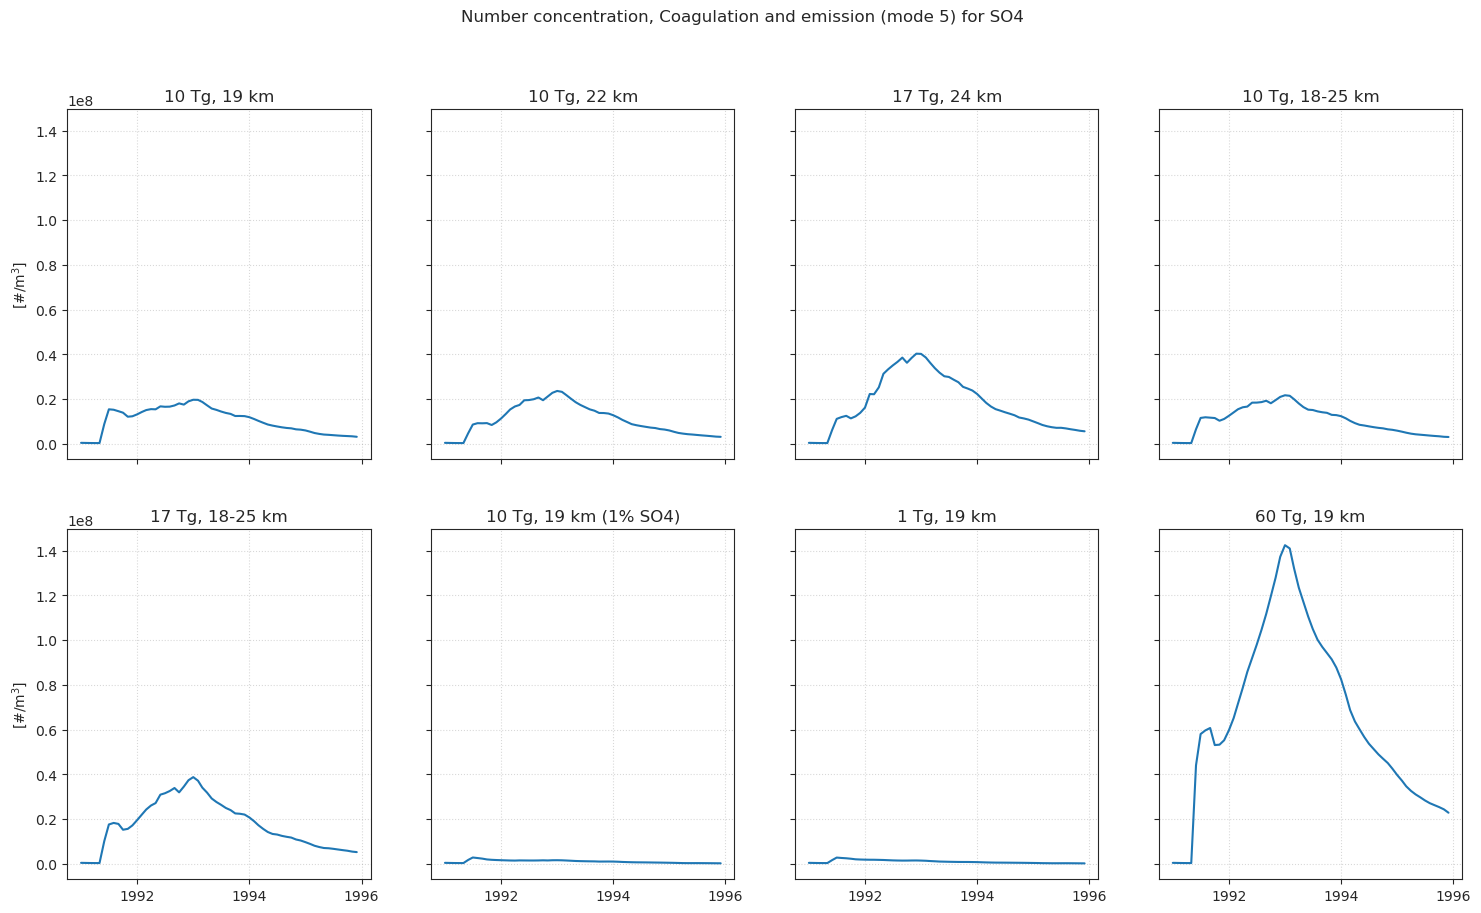

In [57]:
ds = [ds_19_c, ds_22, ds_24, 
      ds_1825, ds_1825_17tg, ds_1pr, 
      ds_1tg, ds_60tg]
levels = [p_lev_19_c, p_lev_22, p_lev_24, 
          p_lev_1825, p_lev_1825_17tg, p_lev_1pr,
          p_lev_1tg, p_lev_60tg]
weights = [weighted_lat_19_c, weighted_lat_22, weighted_lat_24,
           weighted_lat_1825, weighted_lat_1825_17tg, weighted_lat_1pr,
           weighted_lat_1tg, weighted_lat_60tg]

titles = ["10 Tg, 19 km", 
          "10 Tg, 22 km", 
          "17 Tg, 24 km", 
          "10 Tg, 18-25 km", 
          "17 Tg, 18-25 km", 
          "10 Tg, 19 km (1% SO4)", 
          "1 Tg, 19 km", 
          "60 Tg, 19 km"]

fig, axs = plt.subplots(2, 4, figsize=(18, 10), sharex=True, sharey=True)

for ax, current_ds, w, p, title in zip(axs.flat, ds, weights, levels, titles):
    lev_vals = current_ds.lev.values
    lev_diff = np.abs(np.gradient(lev_vals))
    wl = xr.DataArray(lev_diff, coords={'lev': current_ds.lev}, dims=['lev'])
    
    nconc_raw = current_ds["NCONC05"].where(current_ds["lev"] <= p)
    
    nconc_h = nconc_raw.weighted(w).mean(dim=["lat", "lon"])
    nconc_final = nconc_h.weighted(wl).mean(dim="lev")
    nconc_final.plot(ax=ax)
    
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("[#/m$^3$]" if ax in axs[:, 0] else "")
    ax.set_xlabel("") 
    ax.grid(color="gray", alpha=0.3, linestyle=":")

plt.suptitle("Number concentration, Coagulation and emission (mode 5) for SO4")
plt.show()

In [58]:
ds_daily["EC550SO4"]

<xarray.DataArray 'EC550SO4' (time: 30, lev: 32, lat: 192, lon: 288)> Size: 212MB
[53084160 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * time     (time) object 240B 1991-06-02 00:00:00 ... 1991-07-01 00:00:00
Attributes:
    mdims:         1
    units:         m-1
    long_name:     SO4 aerosol extinction coefficient
    cell_methods:  time: mean

Text(0.5, 1.0, 'Stratospheric extinction coefficient of SO$_4$')

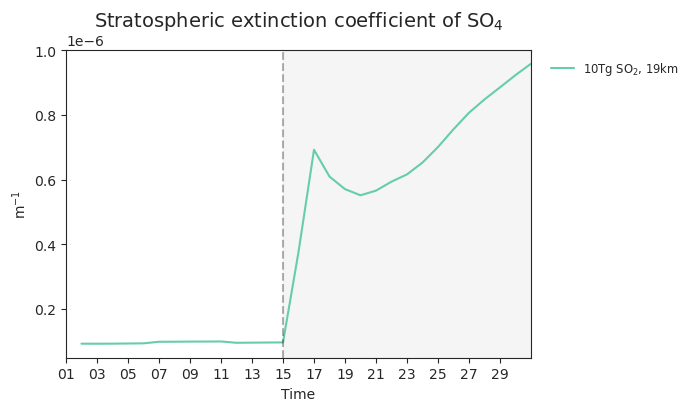

In [59]:
ec = ds_daily["EC550SO4"].where(ds_daily["EC550SO4"]["lev"]<= p_lev_daily)
ec = ec.weighted(weighted_lat_daily).mean(dim=["lev", "lat", "lon"])

fig, ax = plt.subplots(figsize=(6, 4))
ec.plot(color="mediumaquamarine", label="10Tg SO$_2$, 19km")

eruption_date = cftime.DatetimeNoLeap(1991, 6, 15)
end_of_month = cftime.DatetimeNoLeap(1991, 7, 1)

ax.axvline(eruption_date, color='black', linestyle='--', alpha=0.3)
ax.axvspan(eruption_date, end_of_month, color='gray', alpha=0.08, zorder=0)

days = pd.date_range(start="1991-06-01", end="1991-06-30", freq="2D")
day_ticks = [cftime.DatetimeNoLeap(d.year, d.month, d.day) for d in days]

ax.set_xticks(day_ticks)
ax.set_xticklabels([d.strftime('%d') for d in days], rotation=0)
ax.set_xlim(cftime.DatetimeNoLeap(1991, 6, 1), cftime.DatetimeNoLeap(1991, 7, 1)) 

ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize='small', frameon=False)

plt.ylabel("m$^{-1}$")
plt.xlabel("Time")
plt.title("Stratospheric extinction coefficient of SO$_4$", fontsize=14)


In [60]:
def get_weighted_extinction(ds, p_lev, lat_min=-90, lat_max=90):
    ds_area = ds.sel(lat=slice(lat_min, lat_max))
    
    weights_lat = np.cos(np.deg2rad(ds_area.lat))
    weights_lat.name = "weights"
    
    lev_vals = ds_area.lev.values
    lev_diff = np.abs(np.gradient(lev_vals))
    wl = xr.DataArray(lev_diff, coords={'lev': ds_area.lev}, dims=['lev'])
    
    ec = ds_area["EC550SO4"].where(ds_area["lev"] <= p_lev)
    ec_h = ec.weighted(weights_lat).mean(dim=["lat", "lon"])
    ec_final = ec_h.weighted(wl).mean(dim="lev")
    
    return ec_final

In [61]:
ec_19_c = get_weighted_extinction(ds_19_c, p_lev_19_c)
ec_22 = get_weighted_extinction(ds_22, p_lev_22)
ec_24 = get_weighted_extinction(ds_24, p_lev_24)
ec_1825= get_weighted_extinction(ds_1825, p_lev_1825)
ec_1825_17tg = get_weighted_extinction(ds_1825_17tg, p_lev_1825_17tg)
ec_1tg = get_weighted_extinction(ds_1tg, p_lev_1tg)
ec_1pr = get_weighted_extinction(ds_1pr, p_lev_1pr)
ec_60tg= get_weighted_extinction(ds_60tg, p_lev_60tg)

In [62]:
ec_19_c_trop = get_weighted_extinction(ds_19_c, p_lev_19_c, lat_min=-20, lat_max=20)
ec_22_trop = get_weighted_extinction(ds_22, p_lev_22, lat_min=-20, lat_max=20)
ec_24_trop = get_weighted_extinction(ds_24, p_lev_24, lat_min=-20, lat_max=20)
ec_1825_trop = get_weighted_extinction(ds_1825, p_lev_1825, lat_min=-20, lat_max=20)
ec_1825_17tg_trop = get_weighted_extinction(ds_1825_17tg, p_lev_1825_17tg, lat_min=-20, lat_max=20)
ec_1tg_trop = get_weighted_extinction(ds_1tg, p_lev_1tg, lat_min=-20, lat_max=20)
ec_1pr_trop = get_weighted_extinction(ds_1pr, p_lev_1pr, lat_min=-20, lat_max=20)
ec_60tg_trop = get_weighted_extinction(ds_60tg, p_lev_60tg, lat_min=-20, lat_max=20)

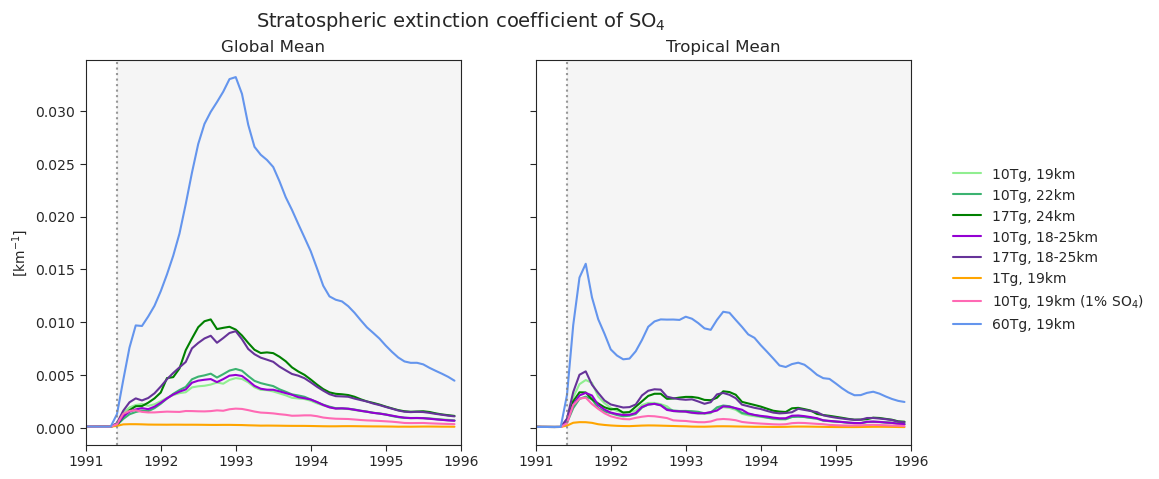

In [63]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].plot(to_float(ec_19_c), ec_19_c* 1000, color="lightgreen", label="10Tg, 19km")
ax[0].plot(to_float(ec_22), ec_22* 1000, color="mediumseagreen", label="10Tg, 22km")
ax[0].plot(to_float(ec_24), ec_24* 1000, color="green", label="17Tg, 24km") 
ax[0].plot(to_float(ec_1825), ec_1825* 1000, color="darkviolet", label="10Tg, 18-25km")
ax[0].plot(to_float(ec_1825_17tg), ec_1825_17tg* 1000, color="rebeccapurple", label="17Tg, 18-25km")
ax[0].plot(to_float(ec_1tg), ec_1tg* 1000, color="orange", label="1Tg, 19km")
ax[0].plot(to_float(ec_1pr), ec_1pr* 1000, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[0].plot(to_float(ec_60tg), ec_60tg* 1000, color="cornflowerblue", label="60Tg, 19km")
ax[0].set_ylabel("[km$^{-1}$]")
ax[0].set_title("Global Mean", fontsize=12)

ax[1].plot(to_float(ec_19_c_trop), ec_19_c_trop* 1000, color="lightgreen", label="10Tg, 19km")
ax[1].plot(to_float(ec_22_trop), ec_22_trop* 1000, color="mediumseagreen", label="10Tg, 22km")
ax[1].plot(to_float(ec_24_trop), ec_24_trop* 1000, color="green", label="17Tg, 24km") 
ax[1].plot(to_float(ec_1825_trop), ec_1825_trop* 1000, color="darkviolet", label="10Tg, 18-25km")
ax[1].plot(to_float(ec_1825_17tg_trop), ec_1825_17tg_trop* 1000, color="rebeccapurple", label="17Tg, 18-25km")
ax[1].plot(to_float(ec_1tg_trop), ec_1tg_trop* 1000, color="orange", label="1Tg, 19km")
ax[1].plot(to_float(ec_1pr_trop), ec_1pr_trop* 1000, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[1].plot(to_float(ec_60tg_trop), ec_60tg_trop* 1000, color="cornflowerblue", label="60Tg, 19km")
ax[1].set_title("Tropical Mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12   

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)


handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Stratospheric extinction coefficient of SO$_4$", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

In [64]:
sageii_tropext = pd.read_csv(f"{path_obs}/sageii_tropical_ext.txt", delim_whitespace=True, header=0,  index_col=0)
start = pd.Timestamp("1991-01-01")
months_sageii = [int(c) for c in sageii_tropext.columns]
dates_sageii = [start + pd.DateOffset(months=m) for m in months_sageii]
sageii_tropext.columns = dates_sageii

levs = sageii_tropext.index.astype(float).values
times = sageii_tropext.columns

sage_da = xr.DataArray(
    sageii_tropext.to_numpy(), 
    dims=("lev", "time"),
    coords={"lev": levs, "time": times}
)

sage_strat = sage_da.where(sage_da.lev <= 100)
lev_diff = np.abs(np.gradient(levs))
wl_sage = xr.DataArray(lev_diff, coords={'lev': levs}, dims=['lev'])

sage_final = sage_strat.weighted(wl_sage).mean(dim="lev")

/tmp/ipykernel_2559790/2946798666.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  sageii_tropext = pd.read_csv(f"{path_obs}/sageii_tropical_ext.txt", delim_whitespace=True, header=0,  index_col=0)


In [65]:
sageii_tropext_err = pd.read_csv(f"{path_obs}/sageii_tropical_ext_err.txt", delim_whitespace=True, header=0, index_col=0)
sageii_tropext_err.columns = dates_sageii 

sage_err_da = xr.DataArray(
    sageii_tropext_err.to_numpy(),
    dims=("lev", "time"),
    coords={"lev": levs, "time": times}
)

sage_err_strat = sage_err_da.where(sage_err_da.lev <= 100)
sage_err_final = sage_err_strat.weighted(wl_sage).mean(dim="lev")

/tmp/ipykernel_2559790/1219481658.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  sageii_tropext_err = pd.read_csv(f"{path_obs}/sageii_tropical_ext_err.txt", delim_whitespace=True, header=0, index_col=0)


In [66]:
glossac_tropext = pd.read_csv(f"{path_obs}/glossac_tropical_ext.txt", delim_whitespace=True, header=0,  index_col=0)
start = pd.Timestamp("1991-01-01")
months_glossac = [int(c) for c in glossac_tropext.columns]
dates_glossac = [start + pd.DateOffset(months=m) for m in months_glossac]
glossac_tropext.columns = dates_glossac

levs = glossac_tropext.index.astype(float).values
times = glossac_tropext.columns

glossac_da = xr.DataArray(
    glossac_tropext.to_numpy(), 
    dims=("lev", "time"),
    coords={"lev": levs, "time": times}
)

glossac_strat = glossac_da.where(glossac_da.lev <= 100)
lev_diff = np.abs(np.gradient(levs))
wl_glossac = xr.DataArray(lev_diff, coords={'lev': levs}, dims=['lev'])

glossac_final = glossac_strat.weighted(wl_glossac).mean(dim="lev")

/tmp/ipykernel_2559790/3142931679.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  glossac_tropext = pd.read_csv(f"{path_obs}/glossac_tropical_ext.txt", delim_whitespace=True, header=0,  index_col=0)


In [67]:
glossac_tropext_err = pd.read_csv(f"{path_obs}/glossac_tropical_ext_err.txt", delim_whitespace=True, header=0, index_col=0)
glossac_tropext_err.columns = dates_glossac

glossac_err_da = xr.DataArray(
    glossac_tropext_err.to_numpy(),
    dims=("lev", "time"),
    coords={"lev": levs, "time": times}
)

glossac_err_strat = glossac_err_da.where(glossac_err_da.lev <= 100)
glossac_err_final = glossac_err_strat.weighted(wl_glossac).mean(dim="lev")

/tmp/ipykernel_2559790/341043329.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  glossac_tropext_err = pd.read_csv(f"{path_obs}/glossac_tropical_ext_err.txt", delim_whitespace=True, header=0, index_col=0)


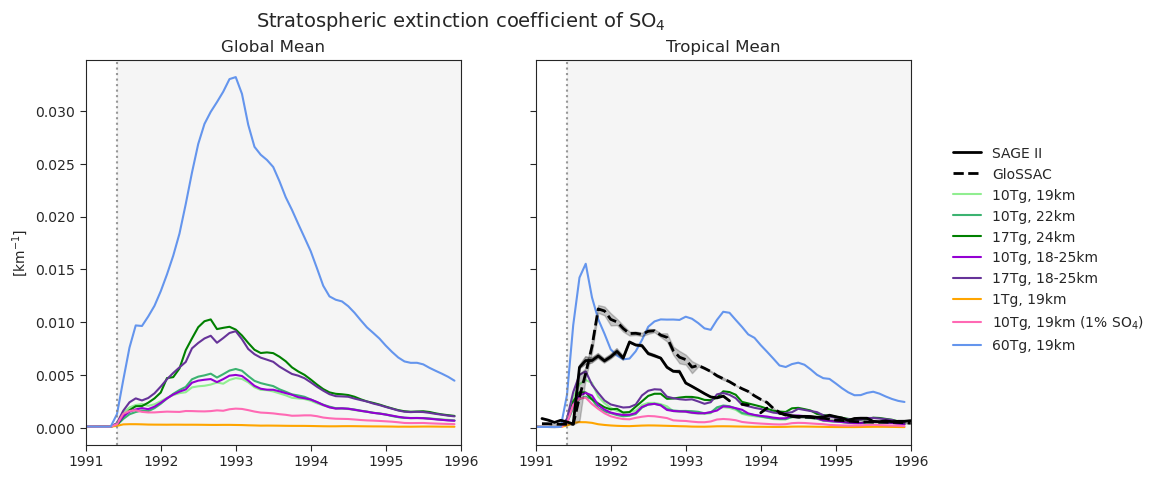

In [68]:
def to_float(x):
    if isinstance(x.time.values[0], np.datetime64):
        times = pd.DatetimeIndex(x.time.values)
        return [t.year + (t.month-1)/12 for t in times]
    else:
        return [t.year + (t.month-1)/12 for t in x.time.values]
    
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

ax[0].plot(to_float(ec_19_c), ec_19_c * 1000, color="lightgreen", label="10Tg, 19km")
ax[0].plot(to_float(ec_22), ec_22* 1000, color="mediumseagreen", label="10Tg, 22km")
ax[0].plot(to_float(ec_24), ec_24* 1000, color="green", label="17Tg, 24km") 
ax[0].plot(to_float(ec_1825), ec_1825* 1000, color="darkviolet", label="10Tg, 18-25km")
ax[0].plot(to_float(ec_1825_17tg), ec_1825_17tg* 1000, color="rebeccapurple", label="17Tg, 18-25km")
ax[0].plot(to_float(ec_1tg), ec_1tg* 1000, color="orange", label="1Tg, 19km")
ax[0].plot(to_float(ec_1pr), ec_1pr* 1000, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[0].plot(to_float(ec_60tg), ec_60tg* 1000, color="cornflowerblue", label="60Tg, 19km")
ax[0].set_ylabel("[km$^{-1}$]")
ax[0].set_title("Global Mean", fontsize=12)

sage_time_float = to_float(sage_final)
ax[1].plot(sage_time_float, sage_final, color="black", linewidth=2, label="SAGE II", zorder=10)
ax[1].fill_between(sage_time_float, 
                   sage_final - sage_err_final, 
                   sage_final + sage_err_final, 
                   color='black', alpha=0.3, zorder=9)
glossac_time_float = to_float(glossac_final)
ax[1].plot(glossac_time_float, glossac_final, color="black", linestyle="--", linewidth=2, label="GloSSAC", zorder=10)
ax[1].fill_between(glossac_time_float, 
                   glossac_final - glossac_err_final, 
                   glossac_final + glossac_err_final, 
                   color='black', alpha=0.2, zorder=9)
ax[1].plot(to_float(ec_19_c_trop), ec_19_c_trop* 1000, color="lightgreen", label="10Tg, 19km")
ax[1].plot(to_float(ec_22_trop), ec_22_trop* 1000, color="mediumseagreen", label="10Tg, 22km")
ax[1].plot(to_float(ec_24_trop), ec_24_trop* 1000, color="green", label="17Tg, 24km") 
ax[1].plot(to_float(ec_1825_trop), ec_1825_trop* 1000, color="darkviolet", label="10Tg, 18-25km")
ax[1].plot(to_float(ec_1825_17tg_trop), ec_1825_17tg_trop* 1000, color="rebeccapurple", label="17Tg, 18-25km")
ax[1].plot(to_float(ec_1tg_trop), ec_1tg_trop* 1000, color="orange", label="1Tg, 19km")
ax[1].plot(to_float(ec_1pr_trop), ec_1pr_trop* 1000, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[1].plot(to_float(ec_60tg_trop), ec_60tg_trop* 1000, color="cornflowerblue", label="60Tg, 19km")
ax[1].set_title("Tropical Mean", fontsize=12)

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)


handles, labels = ax[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Stratospheric extinction coefficient of SO$_4$", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

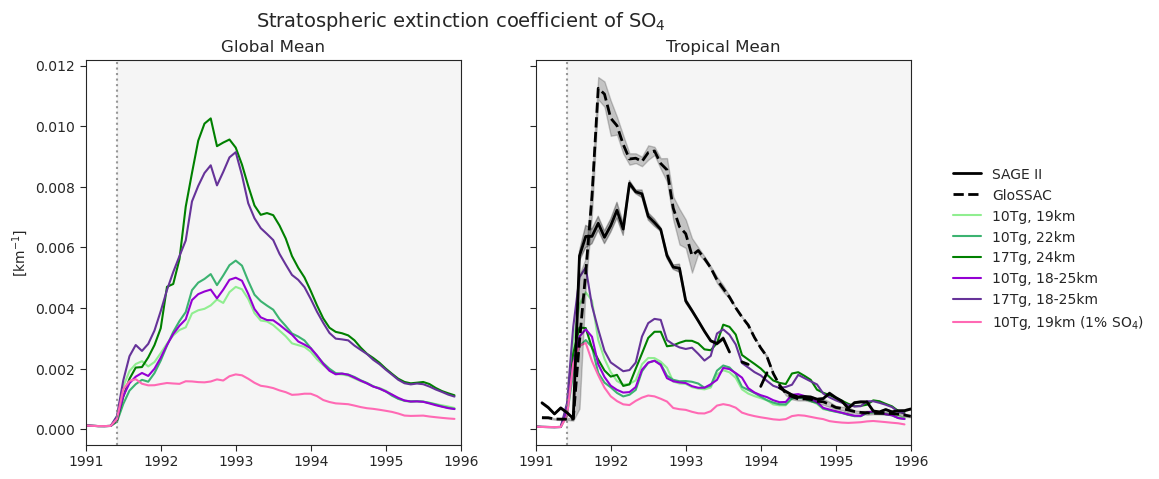

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

ax[0].plot(to_float(ec_19_c), ec_19_c * 1000, color="lightgreen", label="10Tg, 19km")
ax[0].plot(to_float(ec_22), ec_22* 1000, color="mediumseagreen", label="10Tg, 22km")
ax[0].plot(to_float(ec_24), ec_24* 1000, color="green", label="17Tg, 24km") 
ax[0].plot(to_float(ec_1825), ec_1825* 1000, color="darkviolet", label="10Tg, 18-25km")
ax[0].plot(to_float(ec_1825_17tg), ec_1825_17tg* 1000, color="rebeccapurple", label="17Tg, 18-25km")
ax[0].plot(to_float(ec_1pr), ec_1pr* 1000, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[0].set_ylabel("[km$^{-1}$]")
ax[0].set_title("Global Mean", fontsize=12)

sage_time_float = to_float(sage_final)
ax[1].plot(sage_time_float, sage_final, color="black", linewidth=2, label="SAGE II", zorder=10)
ax[1].fill_between(sage_time_float, 
                   sage_final - sage_err_final, 
                   sage_final + sage_err_final, 
                   color='black', alpha=0.3, zorder=9)
glossac_time_float = to_float(glossac_final)
ax[1].plot(glossac_time_float, glossac_final, color="black", linestyle="--", linewidth=2, label="GloSSAC", zorder=10)
ax[1].fill_between(glossac_time_float, 
                   glossac_final - glossac_err_final, 
                   glossac_final + glossac_err_final, 
                   color='black', alpha=0.2, zorder=9)
ax[1].plot(to_float(ec_19_c_trop), ec_19_c_trop* 1000, color="lightgreen", label="10Tg, 19km")
ax[1].plot(to_float(ec_22_trop), ec_22_trop* 1000, color="mediumseagreen", label="10Tg, 22km")
ax[1].plot(to_float(ec_24_trop), ec_24_trop* 1000, color="green", label="17Tg, 24km") 
ax[1].plot(to_float(ec_1825_trop), ec_1825_trop* 1000, color="darkviolet", label="10Tg, 18-25km")
ax[1].plot(to_float(ec_1825_17tg_trop), ec_1825_17tg_trop* 1000, color="rebeccapurple", label="17Tg, 18-25km")
ax[1].plot(to_float(ec_1pr_trop), ec_1pr_trop* 1000, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[1].set_title("Tropical Mean", fontsize=12)

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)


handles, labels = ax[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Stratospheric extinction coefficient of SO$_4$", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

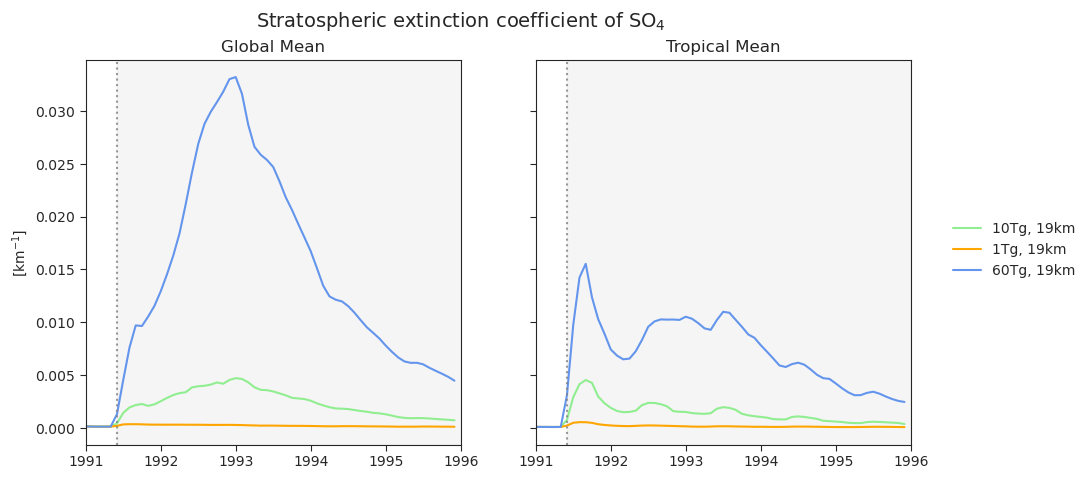

In [70]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].plot(to_float(ec_19_c), ec_19_c* 1000, color="lightgreen", label="10Tg, 19km")
ax[0].plot(to_float(ec_1tg), ec_1tg* 1000, color="orange", label="1Tg, 19km")
ax[0].plot(to_float(ec_60tg), ec_60tg* 1000, color="cornflowerblue", label="60Tg, 19km")
ax[0].set_ylabel("[km$^{-1}$]")
ax[0].set_title("Global Mean", fontsize=12)

ax[1].plot(to_float(ec_19_c_trop), ec_19_c_trop* 1000, color="lightgreen", label="10Tg, 19km")
ax[1].plot(to_float(ec_1tg_trop), ec_1tg_trop* 1000, color="orange", label="1Tg, 19km")
ax[1].plot(to_float(ec_60tg_trop), ec_60tg_trop* 1000, color="cornflowerblue", label="60Tg, 19km")
ax[1].set_title("Tropical Mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12   

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)


handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Stratospheric extinction coefficient of SO$_4$", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()